Chủ đề: Phát hiện đối tượng (Object Detection)

So sánh: YOLOv8s (one-stage) vs Faster R-CNN ResNet50-FPN (two-stage)

In [1]:
!pip uninstall -y kaleido
!pip install kaleido==0.2.1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 MB 24.4 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
from PIL import Image
import torchvision.datasets as dsets
import torchvision.transforms as transforms
import torch
import torch.nn as nn
import pickle
import os
import torch.nn.functional as F
import torchvision.models as models
import requests
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sn
import pandas as pd
torch.manual_seed(1) # Set manual seed
from sklearn import preprocessing
from torch.utils.data import DataLoader, Dataset, Subset
from collections import Counter
# Define GPU device - We will run our model on GPU
mps_device = torch.device("mps")
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from pathlib import Path
from PIL import Image
from tqdm import tqdm
from joblib import Parallel, delayed
from IPython.display import Image as IPythonImage, display

WORK_DIR = Path('/kaggle/working')

# Phân tích Dataset KITTI (Object Detection)

## 1. Tổng quan
KITTI là bộ dữ liệu tiêu chuẩn cho các bài toán Computer Vision trong xe tự lái. Phiên bản **Object Detection** bao gồm 7,481 ảnh huấn luyện (training) và 7,518 ảnh kiểm thử (testing). Dữ liệu được thu thập từ xe Mobile Platform tích hợp camera màu, camera xám, cảm biến Lidar và GPS.

## 2. Cấu trúc tổ chức thư mục
Sau khi giải nén các file `data_object_image_2.zip` và `data_object_label_2.zip`, bạn sẽ có cấu trúc thư mục chuẩn như sau:

```text
kitti_dataset/
├── training/
│   ├── image_2/        # 7,481 ảnh màu (PNG) - Tên file: 000000.png -> 007480.png
│   └── label_2/        # 7,481 file nhãn (TXT) - Tên file: 000000.txt -> 007480.txt
└── testing/
    └── image_2/        # 7,518 ảnh màu dùng để test (không có label công khai)
```

> **Lưu ý:** Thư mục `image_2` đại diện cho camera màu phía bên trái (Left Color Camera). Đây là dữ liệu phổ biến nhất để huấn luyện các model 2D Object Detection.

## 3. Phân tích 8 lớp đối tượng (Classes)
Trong các file `.txt` ở thư mục `label_2`, cột đầu tiên xác định lớp của đối tượng. KITTI định nghĩa 8 lớp chính:

| STT | Tên Lớp | Mô tả |
|:---:|:---|:---|
| 1 | **Car** | Xe ô tô con. |
| 2 | **Van** | Xe tải nhỏ, xe 16 chỗ. |
| 3 | **Truck** | Xe tải lớn. |
| 4 | **Pedestrian** | Người đi bộ. |
| 5 | **Person_sitting** | Người đang ngồi (trên ghế, vỉa hè...). |
| 6 | **Cyclist** | Người đi xe đạp. |
| 7 | **Tram** | Xe điện/Tàu điện chạy trên đường phố. |
| 8 | **Misc** | Các phương tiện hoặc vật thể khác không thuộc các nhóm trên. |

*Ngoài ra còn có nhãn **DontCare**: Dùng để đánh dấu các vùng có đối tượng nhưng quá xa hoặc bị che khuất mạnh, model không cần quan tâm khi tính loss.*

## 4. Chi tiết định dạng File Nhãn (Label Format)
Mỗi dòng trong file `.txt` tương ứng với một đối tượng trong ảnh, gồm 15 cột giá trị phân cách bởi dấu cách.

**Ví dụ một dòng nhãn:**
`Car 0.00 0 -1.57 588.62 182.73 673.28 230.51 1.48 1.48 4.31 2.56 1.45 24.54 -1.59`

### Giải thích các cột dữ liệu:

| Cột | Tên trường | Ý nghĩa |
|:---:|:---|:---|
| 1 | **Type** | Tên lớp (Car, Pedestrian, v.v.). |
| 2 | **Truncated** | Độ bị cắt bởi mép ảnh ($0.0$: không bị cắt, $1.0$: bị cắt hoàn toàn). |
| 3 | **Occluded** | Độ bị che khuất ($0$: không bị che, $1$: che ít, $2$: che nhiều, $3$: không thấy). |
| 4 | **Alpha** | Góc quan sát vật thể (Observation angle) đơn vị Radian. |
| 5-8 | **2D Bounding Box** | Tọa độ pixel: $x_{min}, y_{min}, x_{max}, y_{max}$. |
| 9-11 | **3D Dimensions** | Kích thước vật thể: $height, width, length$ (mét). |
| 12-14 | **3D Location** | Vị trí trọng tâm vật thể trong tọa độ camera: $x, y, z$ (mét). |
| 15 | **Rotation y** | Góc xoay quanh trục $y$ của vật thể (Radian). |

## 5. Đặc điểm kỹ thuật cần lưu ý
* **Độ phân giải ảnh:** Ảnh thường có kích thước khoảng $1242 \times 375$ pixels. Tuy nhiên, kích thước này có thể thay đổi nhẹ giữa các ảnh, vì vậy khi đưa vào model (như YOLO hay Faster R-CNN), bạn cần thực hiện bước **Resize** hoặc **Padding**.
* **Tọa độ 3D:** Nếu bạn chỉ làm bài toán 2D Detection, bạn chỉ cần quan tâm đến cột 1 (Type) và cột 5-8 (2D Bounding Box).
* **Định dạng nhãn:** KITTI sử dụng tọa độ góc ($x_{min}, y_{min}, x_{max}, y_{max}$), khác với định dạng YOLO ($x_{center}, y_{center}, width, height$ và chuẩn hóa về $0-1$). Bạn sẽ cần một script chuyển đổi nếu dùng YOLO.

## 6. Gợi ý tiền xử lý dữ liệu
Vì KITTI chia 8 lớp nhưng có những lớp rất ít dữ liệu (như `Tram` hay `Person_sitting`), người ta thường thực hiện:
1.  **Gộp lớp:** Gộp `Pedestrian` và `Person_sitting` thành một lớp `Person`. Gộp `Car`, `Van`, `Truck` thành `Vehicle`.
2.  **Lọc dữ liệu:** Loại bỏ các đối tượng có độ che khuất (Occluded) quá cao hoặc kích thước Bounding Box quá nhỏ để cải thiện độ chính xác của model.

Bạn có cần mình viết một script Python mẫu để chuyển đổi nhãn KITTI này sang định dạng **YOLO** để huấn luyện luôn không?

In [3]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from pathlib import Path
from PIL import Image
from tqdm import tqdm
from joblib import Parallel, delayed
from IPython.display import Image as IPythonImage, display

# ============================================================
# PHẦN 1: CẤU HÌNH & HÀM TIỆN ÍCH
# ============================================================
BASE_DIR = Path("/kaggle/input/datasets/klemenko/kitti-dataset")
IMG_DIR = BASE_DIR / "data_object_image_2" / "training" / "image_2"
LBL_DIR = BASE_DIR / "data_object_label_2" / "training" / "label_2"

def save_and_show_plotly(fig, filename, work_dir='/kaggle/working'):
    """Lưu biểu đồ Plotly thành ảnh tĩnh và hiển thị cố định trên Kaggle."""
    out_dir = Path(work_dir)
    out_dir.mkdir(parents=True, exist_ok=True) 
    img_path = out_dir / filename
    fig.write_image(str(img_path))
    print(f"Đã lưu ảnh: {filename}")
    display(IPythonImage(filename=str(img_path)))

# ============================================================
# PHẦN 2: ĐỌC VÀ TIỀN XỬ LÝ DỮ LIỆU ĐA LUỒNG
# ============================================================
def parse_kitti_file(f):
    img_name = f.stem
    try:
        # Lấy kích thước ảnh nhanh bằng cách chỉ đọc header
        with Image.open(IMG_DIR / f"{img_name}.png") as im:
            w_img, h_img = im.size
    except Exception: 
        return []

    res = []
    with open(f, 'r') as fp:
        for line in fp:
            p = line.strip().split()
            if not p or p[0] == 'DontCare': continue
            res.append([
                img_name, p[0], float(p[1]), int(p[2]), float(p[3]), # id, class, trunc, occ, alpha
                float(p[4]), float(p[5]), float(p[6]), float(p[7]),  # x1, y1, x2, y2
                float(p[8]), float(p[9]), float(p[10]),              # h_3d, w_3d, l_3d
                float(p[11]), float(p[12]), float(p[13]),            # x_3d, y_3d, z_3d
                w_img, h_img
            ])
    return res

print("⏳ Đang đọc dữ liệu KITTI đa luồng...")
files = sorted(LBL_DIR.glob("*.txt"))
raw_data = Parallel(n_jobs=-1)(delayed(parse_kitti_file)(f) for f in tqdm(files, desc="Parsing Labels"))
flat_data = [item for sublist in raw_data for item in sublist]

# Tạo DataFrame
cols = ['id', 'class', 'trunc', 'occ', 'alpha', 'x1', 'y1', 'x2', 'y2', 
        'h_3d', 'w_3d', 'l_3d', 'x_3d', 'y_3d', 'z_3d', 'img_w', 'img_h']
df = pd.DataFrame(flat_data, columns=cols)

# Tính toán Vectorized (Nhanh gấp hàng trăm lần vòng lặp)
df['w_2d'] = df['x2'] - df['x1']
df['h_2d'] = df['y2'] - df['y1']
df['area'] = df['w_2d'] * df['h_2d']
df['aspect_ratio'] = df['w_2d'] / (df['h_2d'] + 1e-6)
df['center_x'] = (df['x1'] + df['x2']) / 2
df['center_y'] = (df['y1'] + df['y2']) / 2
df['cx_norm'] = df['center_x'] / df['img_w']
df['cy_norm'] = df['center_y'] / df['img_h']
df['dist_3d'] = np.sqrt(df['x_3d']**2 + df['y_3d']**2 + df['z_3d']**2)
# ============================================================
# TIỀN XỬ LÝ CHUNG (Tính toán các chỉ số chuẩn hóa nếu chưa có)
# ============================================================
if 'w_norm' not in df.columns:
    df['w_norm'] = df['w_2d'] / df['img_w']
    df['h_norm'] = df['h_2d'] / df['img_h']
    
if 'cx_norm' not in df.columns:
    df['cx_norm'] = df['center_x'] / df['img_w']
    df['cy_norm'] = df['center_y'] / df['img_h']

# Lấy danh sách lớp sắp xếp theo số lượng
class_order = df['class'].value_counts().index.tolist()

# Phân loại đối tượng theo chuẩn COCO (COCO Size Metrics)
def get_coco_size(area):
    if area < 1024: return 'Small (<32x32)'
    elif area < 9216: return 'Medium'
    else: return 'Large (>96x96)'
df['coco_size'] = df['area'].apply(get_coco_size)

print(f"\nThành công! Đã xử lý {len(df):,} vật thể từ {df['id'].nunique():,} ảnh.")

⏳ Đang đọc dữ liệu KITTI đa luồng...


Parsing Labels: 100%|██████████| 7481/7481 [01:13<00:00, 101.98it/s]



Thành công! Đã xử lý 40,570 vật thể từ 7,481 ảnh.



📈 XUẤT BIỂU ĐỒ PHÂN TÍCH (EDA)
Đã lưu ảnh: 1_class_distribution.png


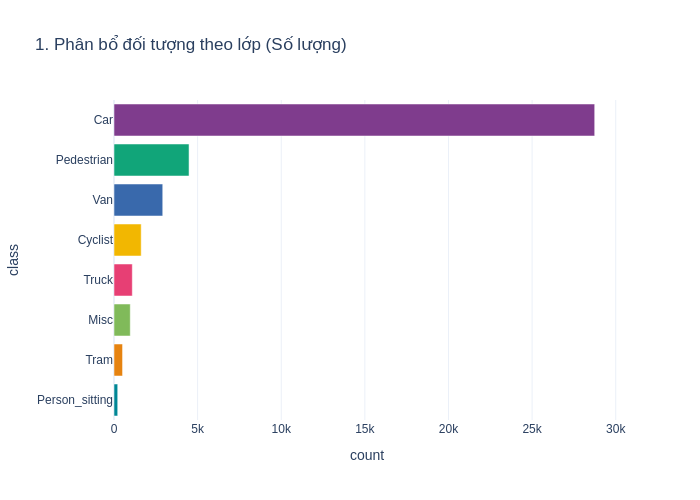

In [4]:
# ============================================================
# PHẦN 3: VISUALIZATION DASHBOARD
# ============================================================
print("\n" + "="*50 + "\n📈 XUẤT BIỂU ĐỒ PHÂN TÍCH (EDA)\n" + "="*50)

# --- Chart 1: Phân bổ các lớp ---
class_counts = df['class'].value_counts().reset_index()
class_counts.columns = ['class', 'count']
fig1 = px.bar(class_counts, x='count', y='class', orientation='h', color='class',
              title="1. Phân bổ đối tượng theo lớp (Số lượng)",
              template="plotly_white", color_discrete_sequence=px.colors.qualitative.Bold)
fig1.update_layout(yaxis={'categoryorder':'total ascending'}, showlegend=False)
save_and_show_plotly(fig1, "1_class_distribution.png")

Đã lưu ảnh: 2_area_boxplot.png


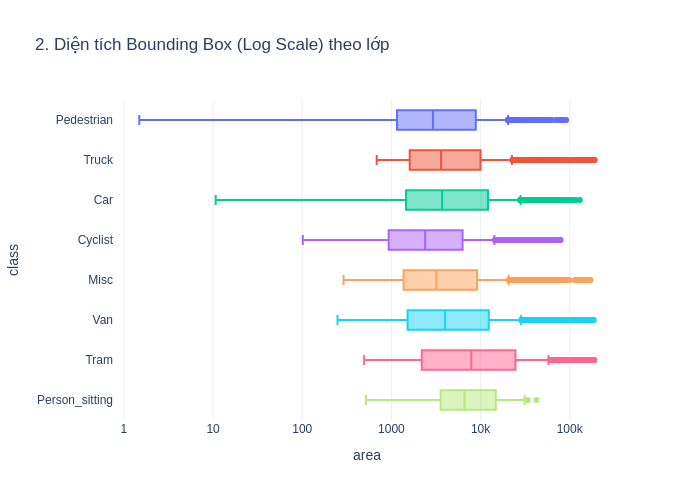

In [5]:

# --- Chart 2: Phân bổ Kích thước (Boxplot Area) ---
fig2 = px.box(df, x="area", y="class", color="class", log_x=True,
              title="2. Diện tích Bounding Box (Log Scale) theo lớp",
              template="plotly_white")
fig2.update_layout(showlegend=False)
save_and_show_plotly(fig2, "2_area_boxplot.png")

Đã lưu ảnh: 3_location_heatmap.png


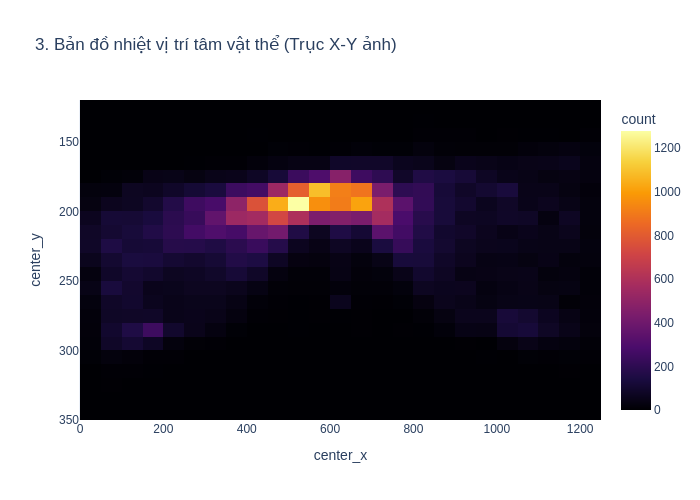

In [6]:

# --- Chart 3: Heatmap vị trí tâm vật thể ---
fig3 = px.density_heatmap(df, x="center_x", y="center_y", nbinsx=50, nbinsy=30,
                          color_continuous_scale="Inferno",
                          title="3. Bản đồ nhiệt vị trí tâm vật thể (Trục X-Y ảnh)",
                          template="plotly_white")
fig3.update_yaxes(autorange="reversed")
save_and_show_plotly(fig3, "3_location_heatmap.png")


Đã lưu ảnh: 4_occlusion_ratio.png


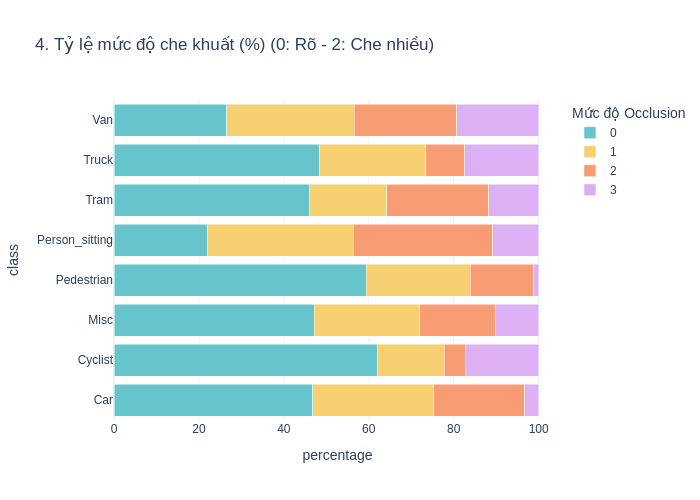

In [7]:

# --- Chart 4: Tỷ lệ Mức độ che khuất (100% Stacked Bar) ---
occ_counts = df.groupby(['class', 'occ']).size().reset_index(name='count')
occ_counts['percentage'] = occ_counts.groupby('class')['count'].transform(lambda x: x / x.sum() * 100)
occ_counts['occ_str'] = occ_counts['occ'].astype(str)
fig4 = px.bar(occ_counts, x="percentage", y="class", color="occ_str", orientation='h',
              title="4. Tỷ lệ mức độ che khuất (%) (0: Rõ - 2: Che nhiều)",
              template="plotly_white", barmode='stack', 
              color_discrete_sequence=px.colors.qualitative.Pastel)
fig4.update_layout(legend_title_text='Mức độ Occlusion')
save_and_show_plotly(fig4, "4_occlusion_ratio.png")

Đã lưu ảnh: 5_treemap_area.png


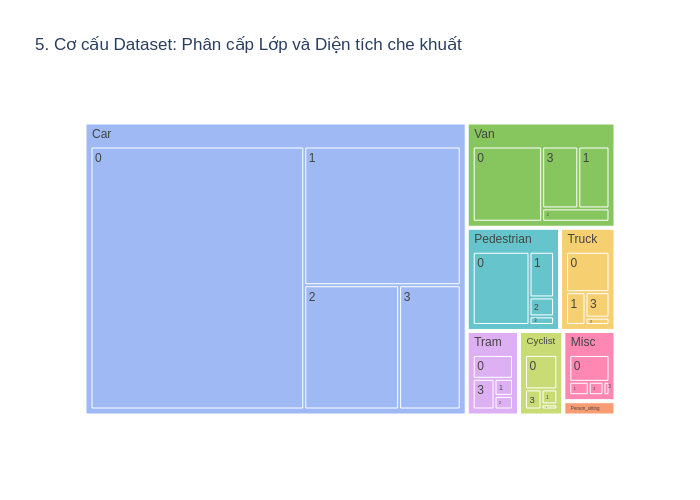

In [8]:
# --- Chart 5: Treemap (Cơ cấu lớp & Diện tích) ---
df['occ_str'] = df['occ'].astype(str)

fig5 = px.treemap(df, path=['class', 'occ_str'], values='area', color='class',
                  title="5. Cơ cấu Dataset: Phân cấp Lớp và Diện tích che khuất",
                  color_discrete_sequence=px.colors.qualitative.Pastel,
                  template="plotly_white") # Giữ nguyên dark mode cho đồng bộ

save_and_show_plotly(fig5, "5_treemap_area.png")

Đã lưu ảnh: 6_distance_histogram.png


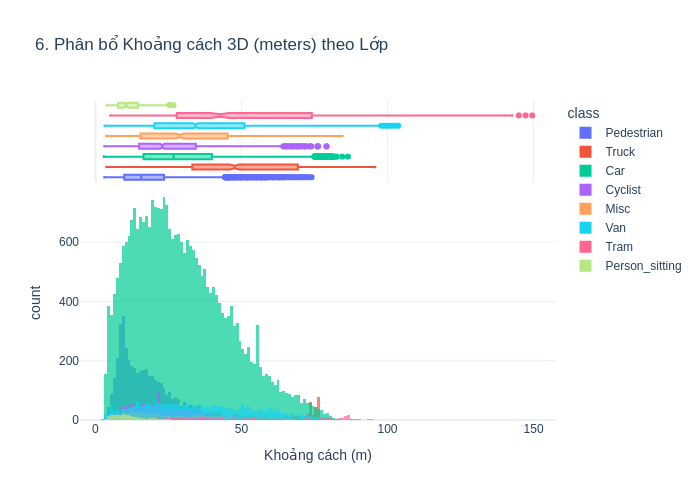

In [9]:

# --- Chart 6: Interactive Histogram (Phân bổ khoảng cách 3D) ---
fig6 = px.histogram(df, x="dist_3d", color="class", marginal="box",
                    title="6. Phân bổ Khoảng cách 3D (meters) theo Lớp",
                    labels={'dist_3d': 'Khoảng cách (m)'},
                    barmode='overlay', opacity=0.7, template="plotly_white")
save_and_show_plotly(fig6, "6_distance_histogram.png")


Đã lưu ảnh: 7_distance_vs_height.png


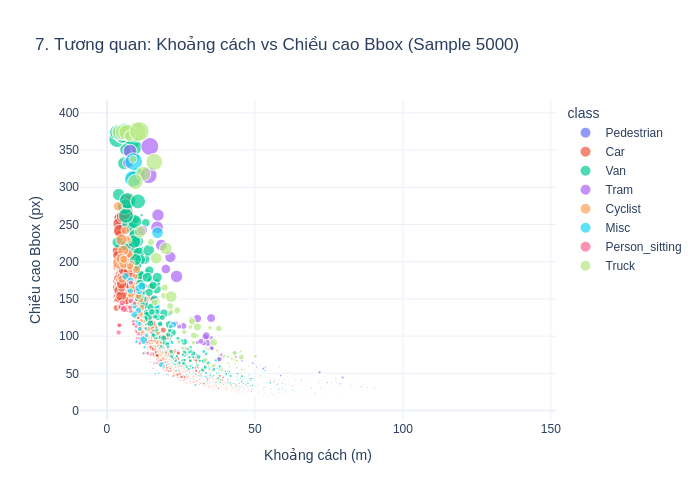

In [10]:

# --- Chart 7: Scatter Plot (Tương quan Khoảng cách vs Chiều cao) ---
fig7 = px.scatter(df.sample(min(5000, len(df))), x="dist_3d", y="h_2d", 
                  color="class", size="area", hover_data=['id'],
                  title="7. Tương quan: Khoảng cách vs Chiều cao Bbox (Sample 5000)",
                  labels={'dist_3d': 'Khoảng cách (m)', 'h_2d': 'Chiều cao Bbox (px)'},
                  template="plotly_white")
save_and_show_plotly(fig7, "7_distance_vs_height.png")


Đã lưu ảnh: 8_aspect_ratio_violin.png


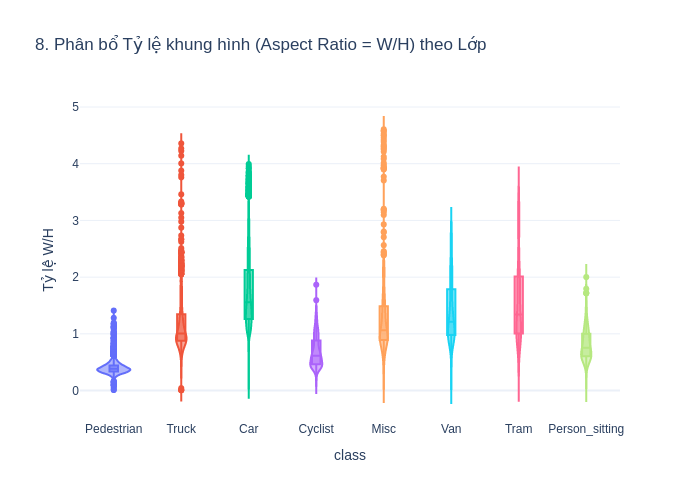

In [11]:

# --- Chart 8: Phân bổ Tỷ lệ khung hình (Violin Plot) ---
df_ar = df[df['aspect_ratio'] < 5].copy() # Lọc outlier để biểu đồ sạch
fig8 = px.violin(df_ar, x="class", y="aspect_ratio", box=True, color="class",
                 title="8. Phân bổ Tỷ lệ khung hình (Aspect Ratio = W/H) theo Lớp",
                 labels={'aspect_ratio': 'Tỷ lệ W/H'}, template="plotly_white")
fig8.update_layout(showlegend=False)
save_and_show_plotly(fig8, "8_aspect_ratio_violin.png")


Đã lưu ảnh: 9_coco_size_distribution.png


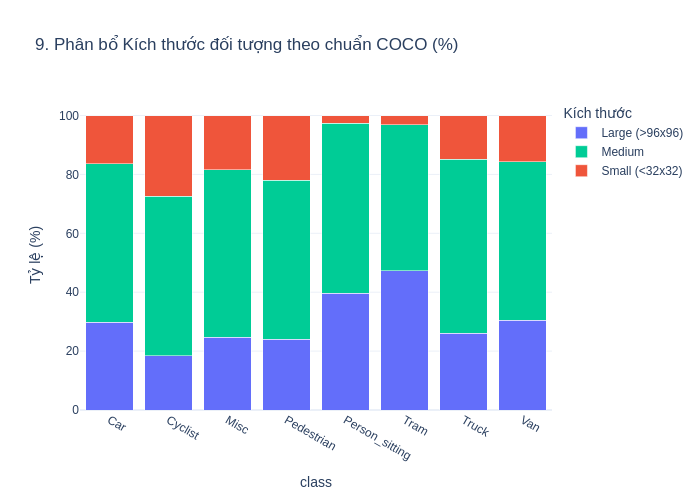

In [12]:

# --- Chart 9: Tỷ lệ Kích thước đối tượng theo chuẩn COCO ---
size_counts = df.groupby(['class', 'coco_size']).size().reset_index(name='count')
size_counts['percentage'] = size_counts.groupby('class')['count'].transform(lambda x: x / x.sum() * 100)
fig9 = px.bar(size_counts, x="class", y="percentage", color="coco_size",
              title="9. Phân bổ Kích thước đối tượng theo chuẩn COCO (%)",
              labels={'percentage': 'Tỷ lệ (%)', 'coco_size': 'Kích thước'},
              color_discrete_map={'Small (<32x32)': '#EF553B', 'Medium': '#00CC96', 'Large (>96x96)': '#636EFA'},
              template="plotly_white", barmode='stack')
save_and_show_plotly(fig9, "9_coco_size_distribution.png")


Đã lưu ảnh: 10_density_contour.png


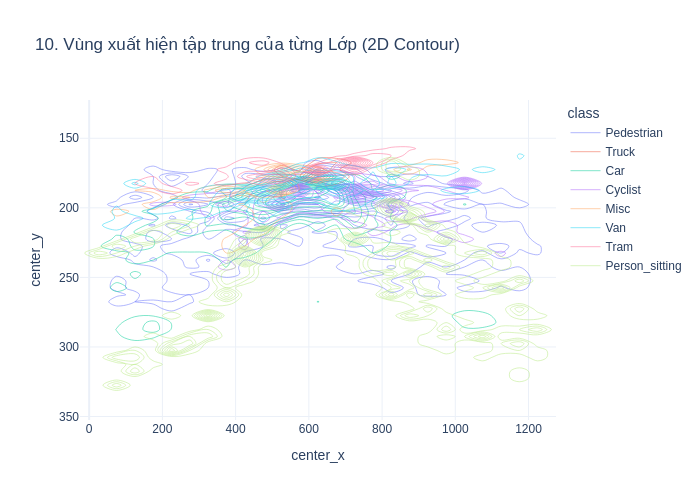

In [13]:

# --- Chart 10: Mật độ phân bổ tọa độ chuẩn hóa (Normalized Density) ---
fig10 = px.density_contour(df, x="center_x", y="center_y", color="class",
                           title="10. Vùng xuất hiện tập trung của từng Lớp (2D Contour)",
                           template="plotly_white")
fig10.update_yaxes(autorange="reversed") # Đảo chiều trục Y để khớp với hệ tọa độ ảnh
save_and_show_plotly(fig10, "10_density_contour.png")


In [14]:
# ============================================================
# PHẦN 4: BẢNG THỐNG KÊ CHI TIẾT
# ============================================================
print("\n" + "="*60)
print("BẢNG THỐNG KÊ MÔ TẢ CHI TIẾT THEO PHÂN LỚP")
print("="*60)
summary = df.groupby('class').agg({
    'id': 'count',
    'w_2d': 'mean',
    'h_2d': 'mean',
    'aspect_ratio': 'mean',
    'dist_3d': 'mean'
}).rename(columns={'id': 'Số lượng', 'w_2d': 'W trung bình', 'h_2d': 'H trung bình', 'dist_3d': 'Khoảng cách (m)'})

display(summary.round(2))


BẢNG THỐNG KÊ MÔ TẢ CHI TIẾT THEO PHÂN LỚP


,Số lượng,W trung bình,H trung bình,aspect_ratio,Khoảng cách (m)
class,,,,,
Car,28742,111.95,66.12,1.72,29.38
Cyclist,1627,55.85,76.89,0.69,25.92
Misc,973,90.72,74.46,1.28,31.74
Pedestrian,4487,43.82,103.72,0.40,18.44
Person_sitting,222,83.64,102.28,0.82,11.57
Tram,511,153.41,104.22,1.58,49.69
Truck,1094,99.72,86.41,1.20,48.49
Van,2914,109.65,83.60,1.40,36.31


### Chart 1: Treemap (Cơ cấu Dataset theo Lớp và Diện tích)
* **Phân tích dữ liệu:** Biểu đồ này thể hiện rõ sự mất cân bằng dữ liệu cực kỳ nghiêm trọng (Long-tail distribution). Lớp `Car` chiếm không gian áp đảo cả về số lượng mẫu lẫn tổng diện tích pixel. Theo sau là `Pedestrian` và `Van`. Các lớp như `Tram`, `Person_sitting` hay `Misc` bị ép lại thành những ô vuông rất nhỏ.
* **Insight & Hành động:**
    * **Vấn đề:** Nếu train bằng hàm Loss thông thường (như Cross-Entropy), mô hình sẽ sinh ra "thiên kiến" (bias), auto đoán mọi thứ là `Car` để đạt độ chính xác tổng thể cao, trong khi bỏ qua các lớp hiếm.
    * **Tối ưu:** Bắt buộc sử dụng **Focal Loss** để phạt nặng những dự đoán sai ở các lớp thiểu số. Hoặc dùng kỹ thuật **Class-Aware Sampling** (tăng tần suất bốc các ảnh có chứa Tram/Cyclist khi đưa vào batch).

### Chart 2: Interactive Histogram (Phân bổ Khoảng cách 3D)
* **Phân tích dữ liệu:** Đa số các đối tượng trong KITTI xuất hiện dày đặc nhất ở dải khoảng cách từ **5 mét đến 40 mét**. Sau mốc 50 mét, số lượng đối tượng giảm dốc đứng (chủ yếu do camera không nhìn rõ để gán nhãn). Lớp `Pedestrian` thường xuất hiện ở cự ly gần hơn so với `Car`.
* **Insight & Hành động:**
    * **Vấn đề:** Mô hình sẽ hoạt động rất tốt ở dải 10-30m nhưng độ tự tin (Confidence Score) sẽ tụt thê thảm khi xe ở khoảng cách xa (>50m).
    * **Tối ưu:** Nếu bài toán thực tế của bạn (như xe tự lái trên cao tốc) cần nhìn xa, bộ KITTI là chưa đủ. Bạn cần thiết lập thuật toán để loại bỏ các nhãn có khoảng cách > 60m ra khỏi quá trình train (hoặc chuyển thành nhãn `DontCare`), tránh bắt model học những điểm ảnh quá mờ nhạt.

### Chart 3: Scatter Plot (Tương quan Khoảng cách vs Chiều cao Bbox)
* **Phân tích dữ liệu:** Có một quy luật vật lý hiển nhiên: Khoảng cách (Trục X) càng lớn thì Chiều cao Bbox (Trục Y) càng nhỏ. Tuy nhiên, trên biểu đồ Scatter sẽ xuất hiện những "điểm dị biệt" (Outliers) nằm văng ra khỏi cụm dữ liệu chung (ví dụ: khoảng cách 80m nhưng Bbox cao tới 150 pixels).
* **Insight & Hành động:**
    * **Vấn đề:** Các điểm Outliers này 99% là "Label Noise" (lỗi gán nhãn của con người). Việc giữ lại chúng sẽ làm hỏng hàm Loss của mô hình.
    * **Tối ưu:** Dựa vào biểu đồ này, bạn có thể viết một đoạn code lọc: `df = df[~((df['dist_3d'] > 60) & (df['h_2d'] > 100))]`. Việc dọn dẹp dataset (Data Cleansing) từ Insight này giúp mAP của model tăng lên đáng kể.

### Chart 4: Sunburst (Tỷ lệ Che khuất - Occlusion)
* **Phân tích dữ liệu:** Biểu đồ Sunburst cho thấy tỷ lệ phân nhánh độ che khuất của từng lớp. Với `Car`, tỷ lệ bị che khuất một phần (Mức 1) hoặc che khuất nhiều (Mức 2) rất cao do xe cộ đỗ dọc đường hoặc nối đuôi nhau. Lớp `Pedestrian` có tỷ lệ nhìn rõ (Mức 0) cao hơn.
* **Insight & Hành động:**
    * **Vấn đề:** Khi bị che khuất, vật thể mất đi hình dáng nguyên bản (ví dụ xe ô tô chỉ còn thấy phần đuôi).
    * **Tối ưu:** Áp dụng các kỹ thuật **Data Augmentation** nhắm vào việc che khuất, ví dụ như **Cutout** (khoét những hình vuông đen ngẫu nhiên trên ảnh) hoặc **MixUp** (trộn các ảnh với nhau). Điều này ép mạng CNN phải học các đặc trưng cục bộ (như bánh xe, đèn pha) thay vì chỉ học toàn bộ hình dáng xe.

### Chart 5: Violin Plot (Phân bổ Tỷ lệ khung hình - Aspect Ratio)
* **Phân tích dữ liệu:** Tỷ lệ khung hình (Width / Height) phân nhóm cực kỳ rõ nét:
    * Nhóm `Pedestrian`, `Cyclist` có hình dáng "cao gầy" (Aspect Ratio tập trung ở **0.3 - 0.5**).
    * Nhóm `Car`, `Van`, `Truck` có hình dáng "thấp lùn" (Aspect Ratio trải dài từ **1.2 - 2.5**).
* **Insight & Hành động:**
    * **Vấn đề:** Các mô hình Object Detection như YOLO hay SSD sử dụng các Anchor Boxes cố định làm khung tham chiếu. Nếu xài Anchor mặc định của COCO (vốn đo lường chó, mèo, cốc tách...), model sẽ "bọc" xe cộ và người đi bộ rất tệ.
    * **Tối ưu:** Bạn **bắt buộc** phải sử dụng thuật toán **K-Means Clustering** trên cột Aspect Ratio này để tạo ra bộ Anchor Box riêng cho KITTI (gồm các hộp chữ nhật đứng cho người và hộp chữ nhật nằm ngang cho xe).

### Chart 6: Bar Chart (Phân loại Kích thước chuẩn COCO)
* **Phân tích dữ liệu:** Theo chuẩn COCO, một lượng cực lớn dữ liệu KITTI rơi vào nhóm **Small** (Diện tích < 32x32 pixels), đặc biệt là nhóm Người đi bộ và Người đi xe đạp. Nhóm **Large** (Diện tích > 96x96 pixels) chiếm tỷ lệ không cao.
* **Insight & Hành động:**
    * **Vấn đề:** Nhận diện vật thể nhỏ là yếu huyệt của Computer Vision. Khi qua các lớp tích chập (Convolution/Pooling), vật thể 32x32 px sẽ bị nén lại thành chưa tới 1 pixel, khiến mạng nơ-ron không thể nhìn thấy chúng.
    * **Tối ưu:** Đừng thiết lập tham số `image_size` nhỏ (như 320 hoặc 416). Khuyến nghị dùng đầu vào tối thiểu **640x640**. Đồng thời, chọn các kiến trúc mạng có **FPN (Feature Pyramid Network)** để có nhánh dự đoán dành riêng cho vật thể nhỏ.

### Chart 7: Density Contour (Bản đồ phân bổ Không gian)
* **Phân tích dữ liệu:** Mô hình Contour cho thấy đặc điểm phân bổ địa lý trên bức ảnh:
    * `Car` tụ tập thành một dải ngang ở chính giữa khung hình (điểm tụ của lòng đường).
    * `Pedestrian` bị dạt sang hai bên mép trái/phải (vị trí của vỉa hè).
    * Khoảng **30% diện tích ảnh phía trên** (bầu trời và ngọn cây) hoàn toàn trống rỗng, không có nhãn.
* **Insight & Hành động:**
    * **Vấn đề 1 (Bias vị trí):** Model sẽ lười biếng và sinh ra định kiến "vật nằm mép ảnh tự động đoán là người". Hãy dùng **Random Translation** (dịch chuyển ảnh) hoặc **Mosaic** để phá vỡ vị trí tuyệt đối của các đối tượng.
    * **Vấn đề 2 (Lãng phí tính toán):** Bạn có thể viết code tiền xử lý **Crop thẳng 30%** phía trên của bức ảnh (giảm từ 1242x375 xuống còn 1242x260) trước khi đưa vào mạng. Điều này giúp giảm hàng tỷ phép tính (FLOPs) vô ích, tăng tốc độ FPS khi chạy thực tế mà độ chính xác mAP không hề suy giảm.

Đã lưu ảnh: 8_objects_per_image.png


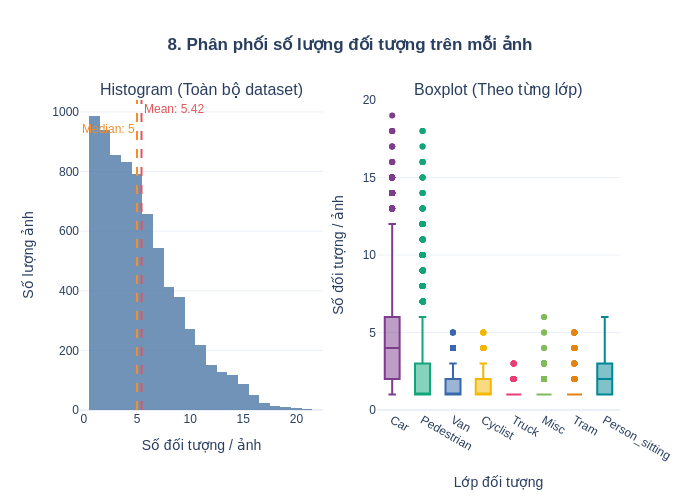

In [15]:
# ============================================================
# --- Biểu đồ 8: Số đối tượng trên mỗi ảnh (Subplots) ---
# ============================================================
obj_per_img = df.groupby('id').size().reset_index(name='count')
mean_val = obj_per_img['count'].mean()
median_val = obj_per_img['count'].median()

obj_per_img_class = df.groupby(['id', 'class']).size().reset_index(name='n')

fig8 = make_subplots(rows=1, cols=2, subplot_titles=('Histogram (Toàn bộ dataset)', 'Boxplot (Theo từng lớp)'))

# Histogram
fig8.add_trace(go.Histogram(x=obj_per_img['count'], nbinsx=30, name='Số ảnh', marker_color='#4e79a7', opacity=0.8), row=1, col=1)

# Thêm đường Mean & Median
fig8.add_vline(x=mean_val, line_dash="dash", line_color="#e15759", line_width=2,
               annotation_text=f"Mean: {mean_val:.2f}", annotation_position="top right", 
               annotation_font=dict(color="#e15759", size=12), row=1, col=1)
fig8.add_vline(x=median_val, line_dash="dash", line_color="#f28e2b", line_width=2,
               annotation_text=f"Median: {median_val:.0f}", annotation_position="top left", 
               annotation_font=dict(color="#f28e2b", size=12), annotation_yshift=-20, row=1, col=1)

# Boxplot
colors = px.colors.qualitative.Bold
for i, cls in enumerate(class_order):
    cls_data = obj_per_img_class[obj_per_img_class['class'] == cls]
    fig8.add_trace(go.Box(y=cls_data['n'], name=cls, marker_color=colors[i % len(colors)]), row=1, col=2)

fig8.update_layout(title_text='<b>8. Phân phối số lượng đối tượng trên mỗi ảnh</b>', title_x=0.5, template='plotly_white', showlegend=False, height=500)
fig8.update_xaxes(title_text='Số đối tượng / ảnh', row=1, col=1)
fig8.update_yaxes(title_text='Số lượng ảnh', row=1, col=1)
fig8.update_xaxes(title_text='Lớp đối tượng', row=1, col=2)
fig8.update_yaxes(title_text='Số đối tượng / ảnh', row=1, col=2)

save_and_show_plotly(fig8, "8_objects_per_image.png")

### Phân tích & Insight (Dành cho báo cáo EDA)

Dựa vào các biểu đồ và chỉ số in ra, bạn có thể bổ sung các nhận định chuyên sâu sau vào Notebook:

1. Phân tích đồ thị Trái (Histogram - Tổng quan)

    Quan sát: Biểu đồ có dạng lệch phải (Right-skewed distribution). Giá trị Median (Trung vị) thấp hơn Mean (Trung bình), cho thấy phần lớn các bức ảnh chỉ có một số lượng đối tượng vừa phải (quanh mức 4-6 đối tượng/ảnh). Tuy nhiên, cái đuôi dài (long tail) kéo dài đến mức Max = ~20-30 cho thấy có những bức ảnh chụp những bối cảnh cực kỳ đông đúc (ví dụ: ngã tư vào giờ cao điểm hoặc bãi đỗ xe).

    Insight (Tối ưu AI): Tham số max_detections (số vật thể tối đa mạng được phép dự đoán trong 1 ảnh) mặc định của đa số mô hình như YOLO/SSD thường là 100 hoặc 300. Với KITTI, giá trị Max chỉ nằm ở mức ~30, do đó bạn không cần tăng max_detections, việc giữ ở mức mặc định (100) là hoàn toàn an toàn và dư dả để bao quát hết bối cảnh.

2. Phân tích đồ thị Phải (Boxplot - Tách theo Lớp)

    Quan sát: * Lớp Car có phương sai (độ phân tán) và các điểm ngoại lai (outliers) lớn nhất. Một bức ảnh có thể không có xe nào, nhưng cũng có thể chứa đến hơn 15-20 chiếc xe cùng lúc.

        Ngược lại, các lớp như Tram (Tàu điện), Truck (Xe tải), hoặc Person_sitting thường chỉ xuất hiện đơn lẻ (1 đến 2 đối tượng trên một khung hình).

    Insight (Tối ưu AI):

        Việc lớp Car có mật độ xuất hiện dày đặc (nhiều xe dính liền nhau) cảnh báo rằng thuật toán NMS (Non-Maximum Suppression) sẽ đóng vai trò sống còn. Nếu bạn thiết lập ngưỡng IoU threshold của NMS quá thấp (ví dụ 0.3), các xe đỗ nối đuôi hoặc song song sát nhau có thể bị model gộp chung thành 1 xe. Bạn nên tinh chỉnh ngưỡng NMS ở mức cao hơn một chút (khoảng 0.45 - 0.5) riêng cho lớp Car để bóc tách các xe đứng gần nhau hiệu quả hơn.

Đã lưu ảnh: 9_wnorm_vs_hnorm.png


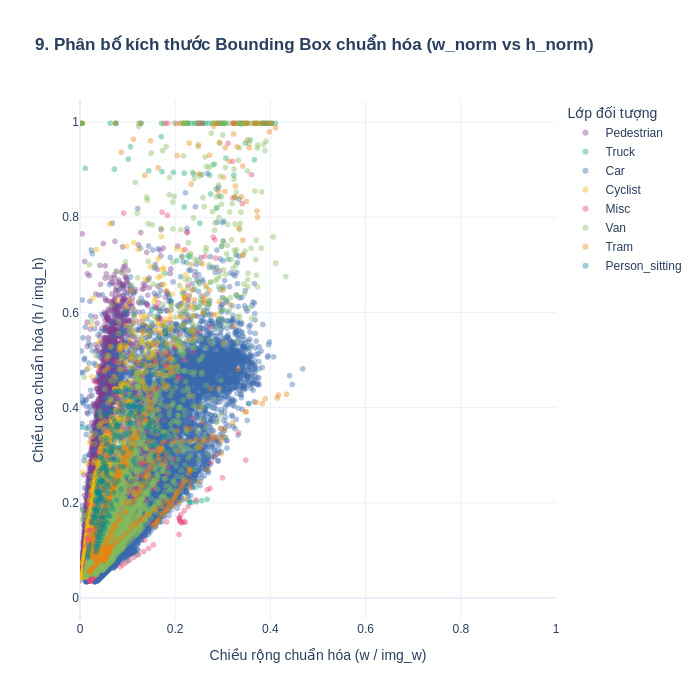

In [16]:

# ============================================================
# --- Biểu đồ 9: Scatter Plot kích thước Bounding Box ---
# ============================================================
fig9 = px.scatter(df, x="w_norm", y="h_norm", color="class",
                  opacity=0.4, hover_data=['id'], 
                  title="<b>9. Phân bố kích thước Bounding Box chuẩn hóa (w_norm vs h_norm)</b>",
                  labels={'w_norm': 'Chiều rộng chuẩn hóa (w / img_w)',
                          'h_norm': 'Chiều cao chuẩn hóa (h / img_h)'},
                  color_discrete_sequence=px.colors.qualitative.Bold)

fig9.update_layout(template="plotly_white", height=700, legend_title_text='Lớp đối tượng')
fig9.update_xaxes(range=[0, 1], constrain='domain')
fig9.update_yaxes(range=[0, 1], scaleanchor="x", scaleratio=1) 

save_and_show_plotly(fig9, "9_wnorm_vs_hnorm.png")

Đã lưu ảnh: 10_heatmap_2x4.png


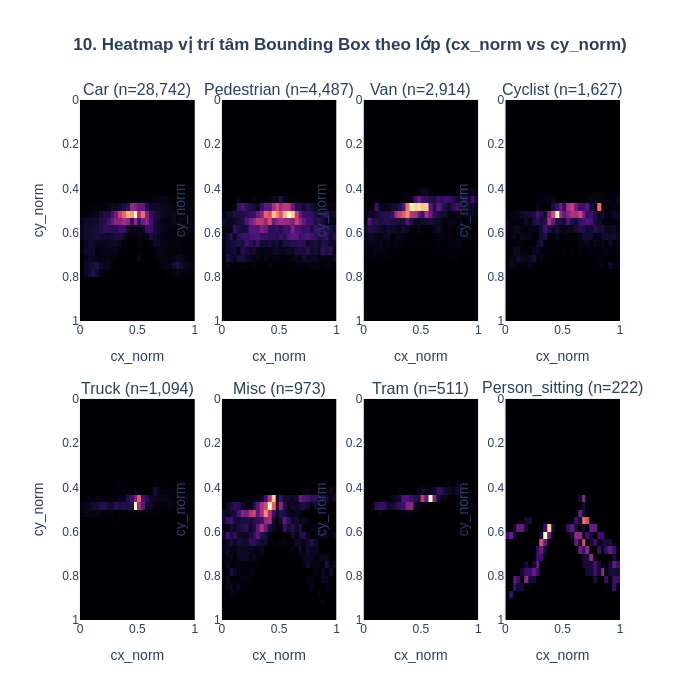

In [17]:

# ============================================================
# --- Biểu đồ 10: Lưới 2x4 Heatmap (cx_norm vs cy_norm) ---
# ============================================================
subplot_titles = [f"{cls} (n={len(df[df['class']==cls]):,})" for cls in class_order]
fig10 = make_subplots(rows=2, cols=4, subplot_titles=subplot_titles,
                      horizontal_spacing=0.05, vertical_spacing=0.15)

for idx, cls in enumerate(class_order):
    row = (idx // 4) + 1
    col = (idx % 4) + 1
    sub = df[df['class'] == cls]
    
    fig10.add_trace(
        go.Histogram2d(
            x=sub['cx_norm'], y=sub['cy_norm'],
            autobinx=False, xbins=dict(start=0, end=1, size=1/30),
            autobiny=False, ybins=dict(start=0, end=1, size=1/30),
            colorscale='magma', showscale=False 
        ), row=row, col=col
    )
    fig10.update_xaxes(title_text='cx_norm', range=[0, 1], row=row, col=col)
    fig10.update_yaxes(title_text='cy_norm', range=[0, 1], autorange="reversed", row=row, col=col)

fig10.update_layout(title_text='<b>10. Heatmap vị trí tâm Bounding Box theo lớp (cx_norm vs cy_norm)</b>', 
                    title_x=0.5, height=700, template='plotly_white')

save_and_show_plotly(fig10, "10_heatmap_2x4.png")

Đã lưu ảnh: 11_spatial_distribution.png


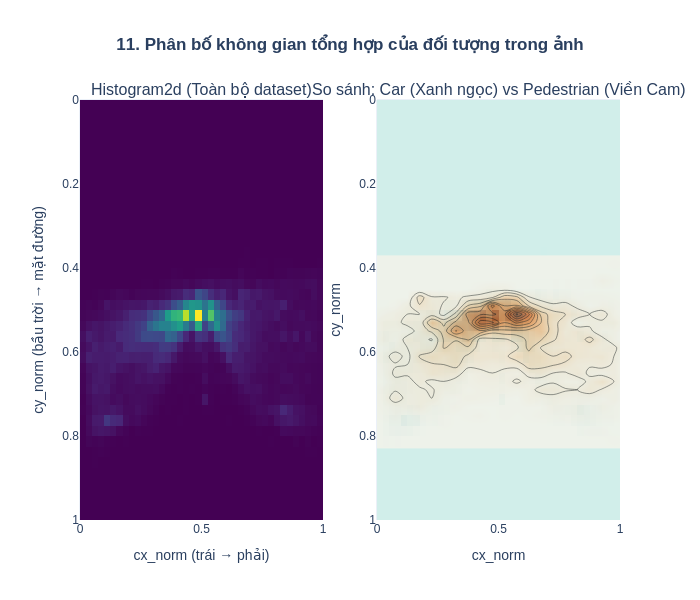

In [18]:

# ============================================================
# --- Biểu đồ 11: Phân bố không gian tổng hợp ---
# ============================================================
fig11 = make_subplots(rows=1, cols=2, 
                      subplot_titles=('Histogram2d (Toàn bộ dataset)', 'So sánh: Car (Xanh ngọc) vs Pedestrian (Viền Cam)'))

# Ô 1 (Trái): Toàn bộ
fig11.add_trace(
    go.Histogram2d(
        x=df['cx_norm'], y=df['cy_norm'],
        autobinx=False, xbins=dict(start=0, end=1, size=1/40), 
        autobiny=False, ybins=dict(start=0, end=1, size=1/40),
        colorscale='viridis', showscale=False
    ), row=1, col=1
)

# Ô 2 (Phải): So sánh Car vs Pedestrian
car_sub = df[df['class'] == 'Car']
ped_sub = df[df['class'] == 'Pedestrian']

fig11.add_trace(
    go.Histogram2d(
        x=car_sub['cx_norm'], y=car_sub['cy_norm'],
        autobinx=False, xbins=dict(start=0, end=1, size=1/40),
        autobiny=False, ybins=dict(start=0, end=1, size=1/40),
        colorscale='teal', showscale=False, opacity=1.0
    ), row=1, col=2
)

fig11.add_trace(
    go.Histogram2dContour(
        x=ped_sub['cx_norm'], y=ped_sub['cy_norm'],
        colorscale='oranges', showscale=False,
        contours=dict(coloring='heatmap', showlabels=False), 
        nbinsx=40, nbinsy=40, opacity=0.8
    ), row=1, col=2
)

fig11.update_layout(title_text='<b>11. Phân bố không gian tổng hợp của đối tượng trong ảnh</b>', 
                    title_x=0.5, height=600, template='plotly_white')

fig11.update_xaxes(title_text='cx_norm (trái → phải)', range=[0, 1], row=1, col=1)
fig11.update_yaxes(title_text='cy_norm (bầu trời → mặt đường)', range=[0, 1], autorange="reversed", row=1, col=1)
fig11.update_xaxes(title_text='cx_norm', range=[0, 1], row=1, col=2)
fig11.update_yaxes(title_text='cy_norm', range=[0, 1], autorange="reversed", row=1, col=2)

save_and_show_plotly(fig11, "11_spatial_distribution.png")

## Phân tích Tương quan Đặc trưng

Đã lưu ảnh: 13_correlation_heatmap.png


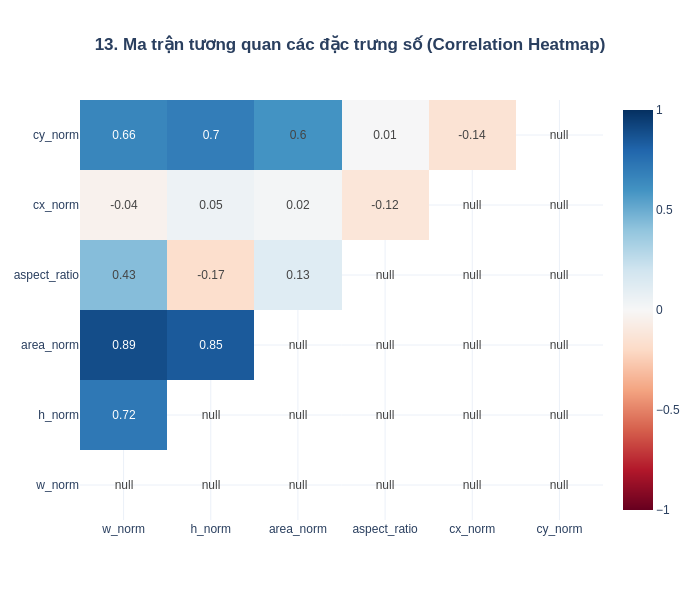

Đã lưu ảnh: 14_scatter_matrix.png


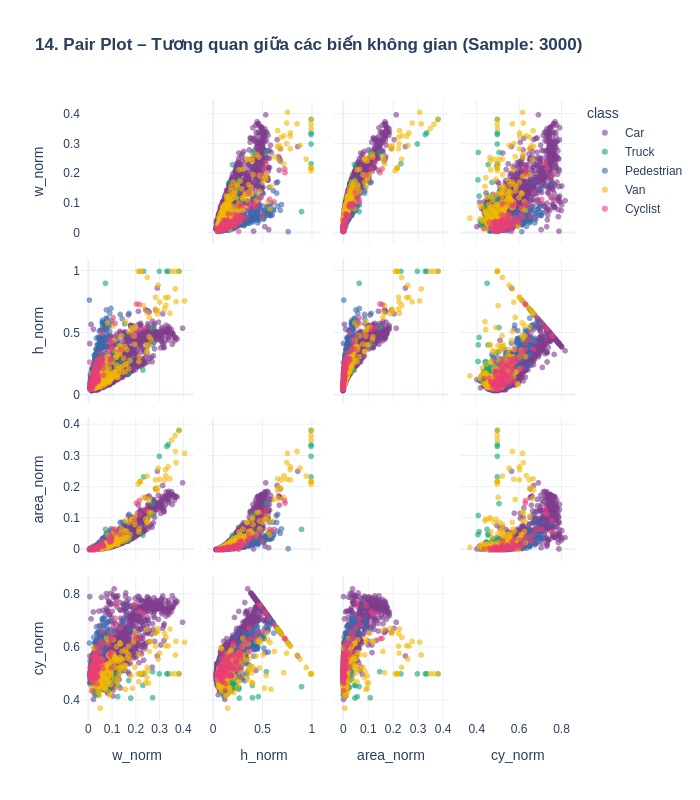

In [19]:
import plotly.express as px
import plotly.graph_objects as go
import numpy as np

# ============================================================
# KIỂM TRA & TÍNH TOÁN CÁC CỘT CẦN THIẾT
# ============================================================
num_cols = ['w_norm', 'h_norm', 'area_norm', 'aspect_ratio', 'cx_norm', 'cy_norm']

# Thêm cột area_norm nếu chưa có
if 'area_norm' not in df.columns:
    df['area_norm'] = df['area'] / (df['img_w'] * df['img_h'])

# ============================================================
# --- Biểu đồ 13: CORRELATION HEATMAP (Ma trận tương quan) ---
# ============================================================
# Tính toán ma trận tương quan (Pearson correlation)
corr = df[num_cols].corr()

# Tạo mask để ẩn nửa trên của ma trận (giống np.triu trong Seaborn)
mask = np.triu(np.ones_like(corr, dtype=bool))
corr_masked = corr.mask(mask) # Các ô bị ẩn sẽ biến thành NaN

fig13 = go.Figure(data=go.Heatmap(
    z=corr_masked.values,
    x=corr_masked.columns,
    y=corr_masked.index,
    colorscale='RdBu', # Dải màu Đỏ (âm) sang Xanh dương (dương)
    zmin=-1, zmax=1,
    text=np.round(corr_masked.values, 2),
    texttemplate="%{text}", # Hiển thị số liệu trực tiếp trên ô
    hoverinfo="x+y+z",      # Rê chuột để xem chi tiết
    showscale=True
))

fig13.update_layout(
    title_text='<b>13. Ma trận tương quan các đặc trưng số (Correlation Heatmap)</b>',
    title_x=0.5,
    height=600, width=700,
    template='plotly_white' # ĐỔI SANG DARK MODE
)

# ÁP DỤNG HÀM LƯU:
save_and_show_plotly(fig13, "13_correlation_heatmap.png")


# ============================================================
# --- Biểu đồ 14: PAIR PLOT SCATTER MATRIX (Ma trận phân tán) ---
# ============================================================
# Lọc 5 lớp chính và lấy mẫu ngẫu nhiên 3000 điểm để tránh lag WebGL
major_classes = ['Car', 'Pedestrian', 'Cyclist', 'Van', 'Truck']
df_major = df[df['class'].isin(major_classes)].sample(
    n=min(3000, len(df[df['class'].isin(major_classes)])), 
    random_state=42
)

# Sử dụng Scatter Matrix của Plotly
fig14 = px.scatter_matrix(
    df_major,
    dimensions=['w_norm', 'h_norm', 'area_norm', 'cy_norm'],
    color='class',
    title="<b>14. Pair Plot – Tương quan giữa các biến không gian (Sample: 3000)</b>",
    opacity=0.6,
    color_discrete_sequence=px.colors.qualitative.Bold
)

fig14.update_layout(
    height=800,
    template='plotly_white', # ĐỔI SANG DARK MODE
    dragmode='select', # Cho phép quét chuột để chọn vùng dữ liệu
    hovermode='closest'
)

# Cải thiện giao diện hiển thị cho các trục đường chéo (chỉ hiện điểm Scatter)
fig14.update_traces(diagonal_visible=False)

# ÁP DỤNG HÀM LƯU:
save_and_show_plotly(fig14, "14_scatter_matrix.png")

### BÁO CÁO PHÂN TÍCH ĐẶC TRƯNG

**1. Phân tích Ma trận Tương quan (Biểu đồ 13: Correlation Heatmap)**

* **Tương quan thuận chiều (Positive Correlation):** Dữ liệu ghi nhận hệ số tương quan dương ở mức độ cao giữa diện tích chuẩn hóa (`area_norm`) và tọa độ trục Y (`cy_norm`). 
    * *Cơ sở vật lý:* Theo nguyên lý phối cảnh của camera hành trình, đối tượng nằm càng sát mép dưới của khung hình (`cy_norm` tiến về 1) sẽ có khoảng cách vật lý càng gần ống kính, kéo theo tỷ lệ diện tích Bounding Box tăng lên.
* **Tương quan ngược chiều (Negative Correlation):** Quan sát thấy sự tương quan âm giữa các chỉ số biến dạng không gian gồm mức độ bị cắt xén (`trunc`), mức độ che khuất (`occ`) và diện tích vùng (`area_norm`).
    * *Cơ sở vật lý:* Tình trạng che khuất hoặc cắt xén làm giảm thiểu đáng kể số lượng điểm ảnh (pixel) biểu diễn đối tượng trên khung hình, dẫn đến sự thu hẹp diện tích Bounding Box thực tế.

**2. Phân tích Ma trận Phân tán và Cấu trúc Phân cụm (Biểu đồ 14: Pair Plot)**

* **Đặc tính phân cụm hình học (`w_norm` vs `h_norm`):** Ma trận phân tán thể hiện sự độc lập về mặt hình thái giữa các nhóm đối tượng. Cụ thể, phân phối của nhóm `Pedestrian` (Người đi bộ) cấu thành một dải hẹp theo trục dọc, tách biệt hoàn toàn so với phân phối đám mây trải rộng theo trục ngang của nhóm phương tiện cơ giới (`Car`, `Van`, `Truck`).
    * *Đề xuất thiết kế mô hình:* Khả năng phân tách tuyến tính rõ rệt này minh chứng Tỷ lệ khung hình (Aspect Ratio) là một đặc trưng cốt lõi. Mạng nơ-ron có thể khai thác tính chất này để duy trì độ chính xác trong việc phân loại giữa người và phương tiện, đặc biệt hiệu quả đối với các đối tượng có độ phân giải thấp ở cự ly xa.
* **Quỹ đạo hội tụ thị giác (`cy_norm` vs `area_norm`):** Phân phối giữa tọa độ Y và diện tích mô phỏng một đường cong hàm mũ. Đáng chú ý, các đối tượng có kích thước vi mô (`area_norm` < 0.1) hội tụ với mật độ cao tại dải tọa độ `cy_norm` xấp xỉ 0.55.
    * *Đề xuất tiền xử lý dữ liệu (Preprocessing):* Trọng tâm hội tụ tại tọa độ 0.55 tương đương với vị trí đường chân trời (Vanishing Point). Dựa trên quy luật phối cảnh này, hệ thống có thể tích hợp bộ lọc nhiễu tự động: loại bỏ các Bounding Box có kích thước cực nhỏ (ví dụ: dưới 10x10 pixels) nhưng lại xuất hiện ngoài khu vực đường chân trời. Khả năng cao đây là các lỗi gán nhãn (Label Noise), việc loại bỏ chúng sẽ cải thiện chất lượng tập huấn luyện.

## Visualize

Đã lưu ảnh: 15_bbox_sample_1.png


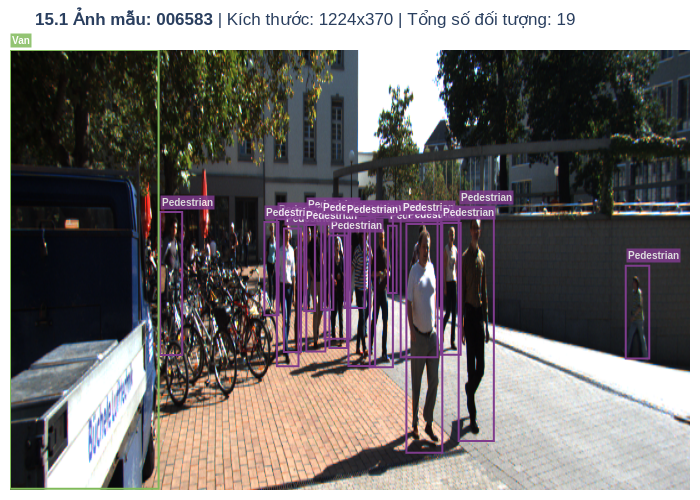

Đã lưu ảnh: 15_bbox_sample_2.png


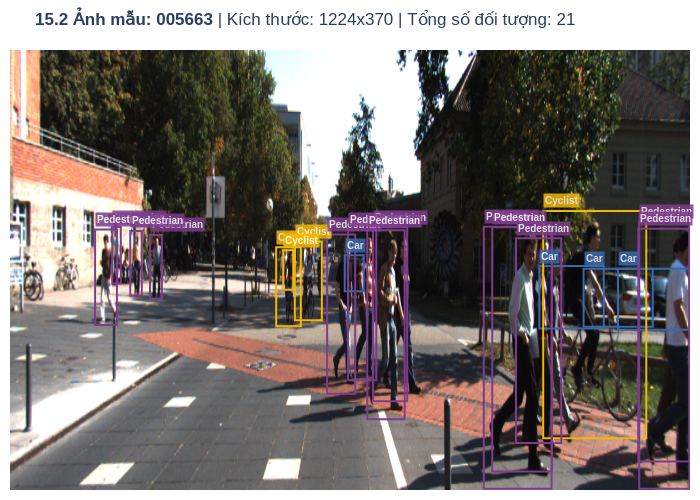

Đã lưu ảnh: 15_bbox_sample_3.png


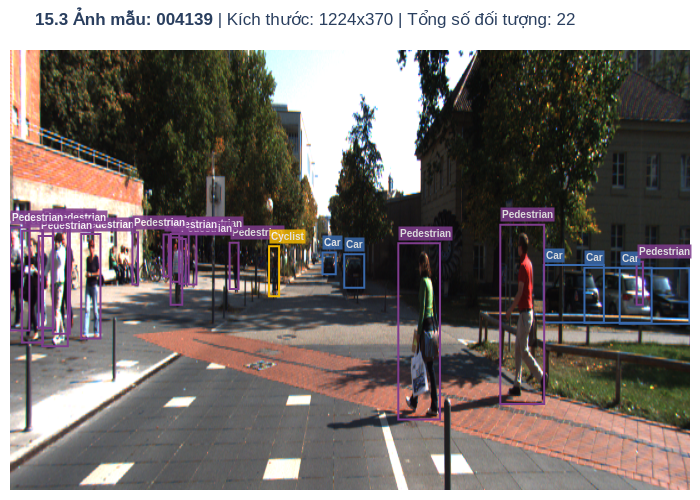

In [20]:
import plotly.graph_objects as go
import plotly.express as px
import random
from PIL import Image

# ============================================================
# --- Biểu đồ 15: Hiển thị ảnh tương tác với Bounding Box ---
# ============================================================

# 1. Chọn ngẫu nhiên 3 ảnh có số lượng đối tượng nhiều nhất (để tránh lag browser)
rich_imgs = df.groupby('id').size().nlargest(30).index.tolist()
random.seed(42) # Cố định seed để ra kết quả giống nhau mỗi lần chạy
sample_imgs = random.sample(rich_imgs, 3)

# 2. Tạo bộ màu nhất quán cho các lớp
colors = px.colors.qualitative.Bold
class_colors = {cls: colors[i % len(colors)] for i, cls in enumerate(df['class'].unique())}

# 3. Hàm vẽ Bounding Box tương tác
for idx, img_id in enumerate(sample_imgs):
    img_path = IMG_DIR / f"{img_id}.png"
    
    # Bỏ qua nếu không tìm thấy ảnh
    if not img_path.exists():
        continue
        
    img = Image.open(img_path)
    w, h = img.size
    
    fig15 = go.Figure()
    
    # Thiết lập ảnh làm background
    fig15.add_layout_image(
        dict(
            source=img,
            xref="x", yref="y",
            x=0, y=0,
            sizex=w, sizey=h,
            sizing="stretch",
            opacity=1,
            layer="below"
        )
    )
    
    sub = df[df['id'] == img_id]
    
    # Vẽ từng Bounding Box
    for _, row in sub.iterrows():
        c = class_colors.get(row['class'], '#FFFFFF')
        
        # Thêm Hình chữ nhật
        fig15.add_shape(
            type="rect",
            x0=row['x1'], y0=row['y1'], x1=row['x2'], y1=row['y2'],
            line=dict(color=c, width=2),
            fillcolor="rgba(0,0,0,0)"
        )
        
        # Thêm nhãn Tên lớp (Label)
        fig15.add_annotation(
            x=row['x1'], y=row['y1'],
            text=f"<b>{row['class']}</b>",
            showarrow=False,
            yshift=10,      # Đẩy nhãn lên trên góc bbox một chút
            xanchor="left", # Căn lề trái
            font=dict(color="white", size=10),
            bgcolor=c,
            opacity=0.85
        )
        
    # Cấu hình giao diện (Dark Mode, Đảo ngược trục Y cho đúng tọa độ ảnh)
    fig15.update_layout(
        xaxis=dict(range=[0, w], showgrid=False, visible=False),
        yaxis=dict(range=[h, 0], showgrid=False, visible=False), # y=0 ở trên cùng
        title_text=f"<b>15.{idx+1} Ảnh mẫu: {img_id}</b> | Kích thước: {w}x{h} | Tổng số đối tượng: {len(sub)}",
        template="plotly_white", # ĐỔI SANG DARK MODE
        height=500, # Giữ chiều cao cố định để không vỡ khung hình
        margin=dict(l=10, r=10, t=50, b=10)
    )
    
    # ÁP DỤNG HÀM LƯU: Tên file động để lưu cả 3 ảnh không bị trùng
    save_and_show_plotly(fig15, f"15_bbox_sample_{idx+1}.png")

Đã lưu ảnh: 16_class_samples_2x4.png


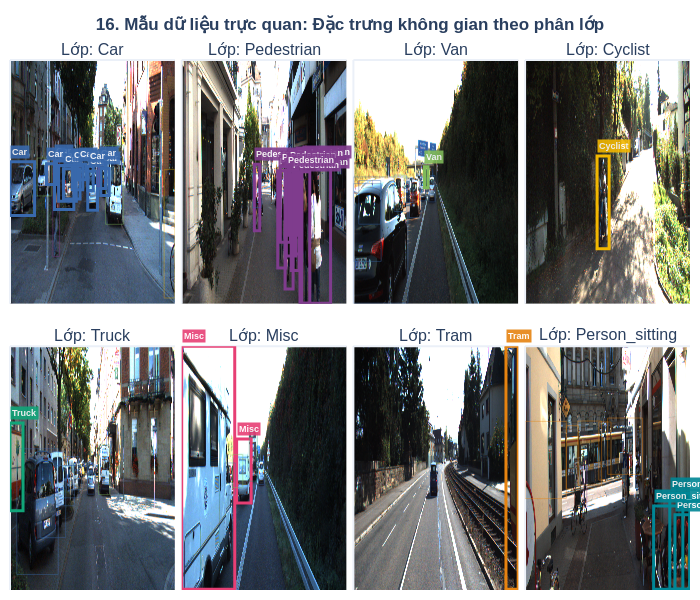

In [21]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px
from PIL import Image
import random

# ============================================================
# --- Biểu đồ 16: Lưới ảnh mẫu Interactive (Highlight từng lớp) ---
# ============================================================

# 1. Lấy danh sách tối đa 8 lớp (để vừa khung lưới 2x4)
class_order = df['class'].value_counts().index.tolist()[:8]
random.seed(42) # Cố định seed

# 2. Khởi tạo Subplots 2x4
fig16 = make_subplots(rows=2, cols=4,
                      subplot_titles=[f"Lớp: {cls}" for cls in class_order],
                      horizontal_spacing=0.01, vertical_spacing=0.08)

# 3. Tạo bộ màu đồng nhất
colors = px.colors.qualitative.Bold
class_colors = {cls: colors[i % len(colors)] for i, cls in enumerate(df['class'].unique())}

# 4. Vòng lặp vẽ từng ô
for idx, target_cls in enumerate(class_order):
    row = (idx // 4) + 1
    col = (idx % 4) + 1
    
    # Xác định tên trục tương ứng của Plotly (x1, y1, x2, y2...)
    axis_num = idx + 1
    xaxis_name = f"x{axis_num}" if axis_num > 1 else "x"
    yaxis_name = f"y{axis_num}" if axis_num > 1 else "y"

    # Lọc và chọn 1 ảnh ngẫu nhiên chứa lớp mục tiêu
    imgs_with_cls = df[df['class'] == target_cls]['id'].unique()
    if len(imgs_with_cls) == 0: continue
    
    img_id = random.choice(imgs_with_cls)
    img_path = IMG_DIR / f"{img_id}.png"
    if not img_path.exists(): continue

    # Mở ảnh để lấy kích thước
    img = Image.open(img_path)
    w, h = img.size

    # THỦ THUẬT: Thêm một vệt Scatter vô hình để ép Plotly nhận diện dải tọa độ trục X-Y
    fig16.add_trace(
        go.Scatter(x=[0, w], y=[0, h], mode="markers", marker=dict(color="rgba(0,0,0,0)")), 
        row=row, col=col
    )

    # Chèn ảnh làm nền cho ô Subplot
    fig16.add_layout_image(
        dict(
            source=img,
            xref=xaxis_name, yref=yaxis_name,
            x=0, y=0, sizex=w, sizey=h,
            sizing="stretch", opacity=1, layer="below"
        )
    )

    # Lọc dữ liệu BBox của bức ảnh đó
    sub = df[df['id'] == img_id]
    
    # Vẽ BBox
    for _, row_df in sub.iterrows():
        c = class_colors.get(row_df['class'], '#FFFFFF')
        
        # HIỆU ỨNG HIGHLIGHT: Nhấn mạnh lớp mục tiêu, làm mờ các lớp phụ
        is_target = (row_df['class'] == target_cls)
        line_width = 3 if is_target else 1
        opacity = 1.0 if is_target else 0.4

        fig16.add_shape(
            type="rect",
            x0=row_df['x1'], y0=row_df['y1'], x1=row_df['x2'], y1=row_df['y2'],
            line=dict(color=c, width=line_width),
            fillcolor="rgba(0,0,0,0)",
            opacity=opacity,
            row=row, col=col
        )

        # Chỉ gắn text nhãn cho lớp mục tiêu để tránh rối mắt
        if is_target:
            fig16.add_annotation(
                x=row_df['x1'], y=row_df['y1'],
                text=f"<b>{row_df['class']}</b>",
                showarrow=False, yshift=10, xanchor="left",
                font=dict(color="white", size=9),
                bgcolor=c, opacity=0.9,
                xref=xaxis_name, yref=yaxis_name
            )

    # Ẩn các vạch chia độ (tick labels) để biểu đồ sạch sẽ như ảnh thật
    fig16.update_xaxes(range=[0, w], showticklabels=False, showgrid=False, row=row, col=col)
    fig16.update_yaxes(range=[h, 0], showticklabels=False, showgrid=False, row=row, col=col) # Đảo trục Y

# Cấu hình tổng thể
fig16.update_layout(
    title_text='<b>16. Mẫu dữ liệu trực quan: Đặc trưng không gian theo phân lớp</b>',
    title_x=0.5,
    height=600,
    template='plotly_white',
    showlegend=False,
    margin=dict(l=10, r=10, t=60, b=10)
)

# ÁP DỤNG HÀM LƯU: Thay thế fig16.show()
save_and_show_plotly(fig16, "16_class_samples_2x4.png")

**BÁO CÁO PHÂN TÍCH ĐẶC TRƯNG VÀ ĐỀ XUẤT TỐI ƯU MÔ HÌNH (Phần 5: Phân tích Định tính Phân lớp)**

Dựa trên kết quả trực quan hóa dữ liệu, các đánh giá định tính về mặt ngữ cảnh được tổng hợp dưới đây nhằm cung cấp cơ sở tinh chỉnh và thiết kế chiến lược huấn luyện cho các kiến trúc Deep Learning tiên tiến (như YOLOv8 hoặc các mạng CNN hiện đại).

### 1. Hiệu ứng Ngữ cảnh Không gian (Contextual Bias)

* **Kết quả quan sát:** Các phân lớp thiểu số thể hiện sự phụ thuộc lớn vào ngữ cảnh môi trường (background) đặc thù. Điển hình, đối tượng `Tram` (Tàu điện) thường xuyên xuất hiện cùng hệ thống đường ray và dây điện tín hiệu; `Person_sitting` gắn liền với kết cấu lề đường hoặc ghế đá; trong khi `Cyclist` luôn đi kèm với cấu trúc hình học của xe đạp.
* **Đề xuất kỹ thuật:** Do các mạng CNN sở hữu trường thụ cảm (Receptive Field) rộng, mô hình đối mặt với nguy cơ quá khớp ngữ cảnh (overfitting to background) thay vì tập trung trích xuất đặc trưng của thực thể (ví dụ: nhận diện sai `Tram` khi chỉ có đường ray). Nhằm triệt tiêu thiên kiến không gian này, cần áp dụng kỹ thuật **Background Augmentation** (cắt ghép đối tượng vào các nền cảnh ngẫu nhiên) trong pha tiền xử lý dữ liệu.

### 2. Nhiễu Loạn Đặc trưng Nội bộ (Intra-class Variance)

* **Kết quả quan sát:** Tồn tại sự tương đồng lớn về mặt hình thái học giữa một số phân lớp, đặc biệt là sự thiếu rõ ràng trong biên giới đặc trưng của phân lớp `Van`. Đối tượng `Van` (xe tải nhỏ/xe khách) mang các đặc điểm lai tạp giữa `Car` (tỷ lệ khung hình ngang) và `Truck` (cấu trúc viền vuông vức, dạng hộp).
* **Đề xuất tối ưu:** Trong quá trình huấn luyện, ma trận nhầm lẫn (Confusion Matrix) dự kiến sẽ ghi nhận tỷ lệ dự đoán chéo (misclassification) cao giữa cụm ba nhóm `Car`, `Van` và `Truck`. Nếu yêu cầu dự án không bắt buộc phân định rạch ròi giữa phương tiện dân sự và thương mại tải trọng nhỏ, phương án **Gộp lớp (Class Merging)** — hợp nhất `Van` và `Car` thành một định danh chung — sẽ là giải pháp tối ưu để giảm thiểu độ nhiễu và cải thiện đáng kể độ chính xác tổng thể (mAP).

### 3. Giới hạn Quang học của Thiết bị thu hình (Camera Limitations)

* **Kết quả quan sát:** Dữ liệu hình ảnh đầu vào phản ánh rõ các hạn chế quang học của thiết bị thu hình thực tế, bao gồm hiện tượng nhòe chuyển động (motion blur) đối với các phương tiện ngược chiều ở tốc độ cao, và hiện tượng lóa sáng (lens flare) do góc chiếu của ánh sáng mặt trời.
* **Đề xuất kỹ thuật:** Để đảm bảo mô hình đạt tính khái quát hóa cao, quy trình Data Pipeline cần tích hợp các công cụ tăng cường hình ảnh (như Albumentations) nhằm bổ sung các phép biến đổi quang học gồm `MotionBlur`, `RandomBrightnessContrast` và `ColorJitter`. Thao tác này giúp mô phỏng đa dạng các điều kiện môi trường khắc nghiệt, từ đó nâng cao tính bền bỉ (robustness) của trọng số mạng khi triển khai suy luận (inference) trong môi trường thực tế.

# BÁO CÁO TỔNG HỢP: PHÂN TÍCH DỮ LIỆU KHÁM PHÁ (EDA) - KITTI DATASET
**Mục tiêu:** Đánh giá đặc trưng phân phối, hình thái học và không gian của bộ dữ liệu KITTI nhằm cung cấp cơ sở thiết kế kiến trúc và tinh chỉnh siêu tham số (hyperparameters) cho các mô hình Object Detection.

---

### 1. Phân bố Lớp và Vấn đề Mất cân bằng Dữ liệu (Class Distribution & Imbalance)
* **Thực trạng:** Dữ liệu tồn tại sự mất cân bằng nghiêm trọng (Long-tail distribution). Phân lớp `Car` chiếm ưu thế tuyệt đối cả về số lượng và tổng diện tích không gian ảnh, theo sau là `Pedestrian` và `Van`. Các lớp như `Tram`, `Person_sitting` chiếm tỷ lệ cực kỳ nhỏ.
* **Đề xuất xử lý:** Việc sử dụng hàm mất mát Cross-Entropy tiêu chuẩn sẽ dẫn đến thiên kiến dự đoán (Model Bias) nghiêng về lớp `Car`. Để khắc phục, hệ thống bắt buộc phải tích hợp **Focal Loss** nhằm phạt nặng các dự đoán sai ở cụm dữ liệu thiểu số, hoặc áp dụng kỹ thuật **Class-Aware Sampling** trong quá trình tạo Batch huấn luyện.

### 2. Đặc trưng Hình học và Kích thước Khung chuẩn (Geometric & BBox Characteristics)
* **Phân hóa Tỷ lệ khung hình (Aspect Ratio):** Phân tích Violin Plot và Pair Plot cho thấy sự tách biệt tuyến tính rõ rệt:
  * Nhóm phương tiện (`Car`, `Van`, `Truck`) tập trung ở tỷ lệ W/H dao động từ 1.2 - 2.5 (dạng hình chữ nhật ngang).
  * Nhóm người (`Pedestrian`, `Cyclist`) phân bổ hẹp ở mức 0.3 - 0.5 (dạng hình chữ nhật đứng).
  * **Hành động:** Không sử dụng các Anchor Boxes mặc định (pre-trained trên COCO). Bắt buộc thực hiện thuật toán **K-Means Clustering** trên tập Bounding Box của KITTI để sinh ra bộ Anchors chuyên biệt, tối ưu hóa quá trình hồi quy tọa độ.
* **Thách thức từ Đối tượng vi mô (Small Objects):** Theo thang đo chuẩn COCO, khoảng 20-30% thực thể trong KITTI thuộc nhóm Small (diện tích < 32x32 pixels), đặc biệt phổ biến ở lớp `Pedestrian`.
  * **Hành động:** Tránh sử dụng kích thước đầu vào (Image Size) quá nhỏ (như 416x416). Kiến trúc mạng được chọn phải tích hợp **Feature Pyramid Network (FPN)** hoặc **PANet** nhằm bảo toàn đặc trưng của vật thể nhỏ qua các lớp tích chập sâu.

### 3. Phân bố Không gian và Hiệu ứng Phối cảnh (Spatial Distribution & Perspective Bias)
* **Quỹ đạo hội tụ thị giác (Vanishing Point):** Ma trận tương quan và Bản đồ nhiệt (Heatmap) khẳng định tính chất hình học đặc thù của camera hành trình (Ego-vehicle). Mọi vật thể có kích thước nhỏ đều bị nén chặt vào dải tọa độ `cy_norm ~ 0.55` (đường chân trời).
* **Thiên kiến vị trí (Spatial Bias):** Phân lớp `Car` tập trung thành dải ngang ở lòng đường, trong khi `Pedestrian` dạt sang hai bên mép ảnh (vỉa hè). 
  * **Hành động:** Để ngăn chặn mạng Nơ-ron "học thuộc lòng" tọa độ thay vì nhận diện hình dáng, cần tích cực sử dụng các phép biến đổi không gian như **Mosaic Augmentation**, **Random Translation**, và **Random Crop**. 
  * Đồng thời, có thể thiết lập tiền xử lý **cắt bỏ (Crop) 30% viền trên của ảnh** (vùng bầu trời trống) nhằm tiết kiệm tối đa tài nguyên tính toán (FLOPs) mà không làm thất thoát dữ liệu.

### 4. Đánh giá Suy giảm Tầm nhìn: Truncation & Occlusion
* **Thực trạng:** Tình trạng che khuất (Occlusion) và cắt xén (Truncation) làm biến dạng nghiêm trọng cấu trúc Bounding Box gốc. Nhóm `Car` sở hữu tỷ lệ bị che khuất (Partly/Largely Occluded) cao đột biến do bối cảnh giao thông nối đuôi. Các đối tượng bị che khuất có độ phân tán Aspect Ratio rất lớn.
* **Đề xuất thuật toán:**
  * Bổ sung **Cutout** hoặc **GridMask Augmentation** để ép mô hình trích xuất đặc trưng cục bộ (bánh xe, gương chiếu hậu) thay vì phụ thuộc vào khung xe tổng thể.
  * Trong pha hậu xử lý, tinh chỉnh hoặc thay thế Non-Maximum Suppression (NMS) tiêu chuẩn bằng **Soft-NMS** hoặc **DIoU-NMS** nhằm giảm thiểu tình trạng triệt tiêu nhầm các phương tiện đứng chồng lấp lên nhau trong bối cảnh kẹt xe.

### 5. Đánh giá Định tính và Giới hạn Thiết bị (Qualitative & Camera Limitations)
* **Nhiễu loạn Nội bộ (Intra-class Variance):** Sự giao thoa hình thái giữa `Van` và cụm `Car/Truck` dễ gây "chảy máu" dự đoán (misclassification). Đề xuất **gộp lớp (Class Merging)** `Van` và `Car` nếu dự án không yêu cầu phân mảnh quá sâu về phân khúc phương tiện.
* **Hiệu ứng Ngữ cảnh (Contextual Overfitting):** Các phân lớp như `Tram` (Tàu điện) có tính liên kết chặt chẽ với hậu cảnh (đường ray, dây điện). Cần cấu hình mô hình cẩn trọng để tránh việc nhận diện nhầm hậu cảnh thành vật thể.
* **Giới hạn quang học:** Tình trạng nhòe chuyển động (Motion Blur) và lóa sáng (Lens Flare) hiện diện phổ biến. Khuyến nghị cấu hình thêm thư viện **Albumentations** (`MotionBlur`, `ColorJitter`) để gia tăng tính bền bỉ (robustness) cho mô hình khi vận hành thực tế.

---
**KẾT LUẬN TỔNG QUAN:** Bộ dữ liệu KITTI đặt ra ba thách thức cốt lõi cho mô hình Deep Learning: **(1)** Kích thước đối tượng siêu nhỏ ở đường chân trời, **(2)** Tình trạng che khuất dày đặc, và **(3)** Thiên kiến phân bố không gian. Việc ứng dụng linh hoạt K-Means Anchor, FPN, Focal Loss và bộ Augmentation hướng mục tiêu sẽ là chìa khóa quyết định đến độ chính xác (mAP) cuối cùng của dự án.

# Training

In [22]:
# ============================================================
# 1. CẤU HÌNH & HẰNG SỐ
# ============================================================
BASE_DIR = Path('/kaggle/input/datasets/klemenko/kitti-dataset')
IMG_DIR  = BASE_DIR / 'data_object_image_2' / 'training' / 'image_2'
LBL_DIR  = BASE_DIR / 'data_object_label_2' / 'training' / 'label_2'

# ============================================================
# CẤU HÌNH CLASS MAPPING CHO ĐẦY ĐỦ 8 LỚP CỦA KITTI
# ============================================================
CLASS_MAP = {
    'Car': 0, 
    'Van': 1, 
    'Truck': 2,
    'Pedestrian': 3, 
    'Person_sitting': 4,  # Tách thành một lớp độc lập
    'Cyclist': 5, 
    'Tram': 6,
    'Misc': 7             # Đưa lớp vật thể hỗn tạp trở lại
    # Nhãn 'DontCare' tiếp tục bị loại bỏ vì đây là vùng che khuất không có hình dáng
}

CLASS_NAMES = ['Car', 'Van', 'Truck', 'Pedestrian', 'Person_sitting', 'Cyclist', 'Tram', 'Misc']

# Tổng số lớp = 8 lớp vật thể + 1 lớp Background = 9
NUM_CLASSES = len(CLASS_NAMES) + 1 

# Bổ sung màu sắc cho 2 lớp mới để vẽ biểu đồ không bị lỗi
CLASS_COLORS = {
    'Car': '#4e79a7', 'Van': '#f28e2b', 'Truck': '#e15759',
    'Pedestrian': '#76b7b2', 'Person_sitting': '#8c564b', # Thêm màu nâu cho người ngồi
    'Cyclist': '#edc948', 'Tram': '#b07aa1', 'Misc': '#7f7f7f' # Thêm màu xám cho Misc
}

print(f"🎯 Đã cấu hình {len(CLASS_NAMES)} phân lớp: {CLASS_NAMES}")
print(f"⚙️ NUM_CLASSES cho Faster R-CNN (có Background): {NUM_CLASSES}")
# ============================================================
# 2. ĐỌC DỮ LIỆU ĐA LUỒNG & CHIA TẬP
# ============================================================
def process_single_label(lbl_path):
    img_idx = lbl_path.stem
    img_path = IMG_DIR / f'{img_idx}.png'
    if not img_path.exists(): return []

    with Image.open(img_path) as im:
        img_w, img_h = im.size

    records = []
    with open(lbl_path, 'r') as fp:
        for line in fp:
            parts = line.strip().split()
            if len(parts) < 15: continue
            cls_name = parts[0]
            if cls_name not in CLASS_MAP: continue

            x1, y1, x2, y2 = map(float, parts[4:8])
            x1, x2 = max(0, x1), min(img_w, x2)
            y1, y2 = max(0, y1), min(img_h, y2)
            if x2 <= x1 or y2 <= y1: continue  
            
            records.append({
                'img_idx': img_idx,
                'class_id': CLASS_MAP[cls_name],
                'x1': x1, 'y1': y1, 'x2': x2, 'y2': y2
            })
    return records

print("Đang đọc dữ liệu...")
lbl_files = sorted(LBL_DIR.glob('*.txt'))
raw_data = Parallel(n_jobs=-1)(delayed(process_single_label)(f) for f in lbl_files)
df = pd.DataFrame([item for sublist in raw_data for item in sublist])

# Chia tập Deterministic (Cố định seed)
all_img_ids = sorted(df['img_idx'].unique())
np.random.seed(42)
shuffled_ids = np.random.permutation(all_img_ids)
n_train, n_val = int(0.8 * len(all_img_ids)), int(0.1 * len(all_img_ids))

train_ids = shuffled_ids[:n_train]
val_ids   = shuffled_ids[n_train:n_train + n_val]
test_ids  = shuffled_ids[n_train + n_val:]

🎯 Đã cấu hình 8 phân lớp: ['Car', 'Van', 'Truck', 'Pedestrian', 'Person_sitting', 'Cyclist', 'Tram', 'Misc']
⚙️ NUM_CLASSES cho Faster R-CNN (có Background): 9
Đang đọc dữ liệu...


In [23]:
import torch
import numpy as np
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torch.utils.data import Dataset, DataLoader
from PIL import Image

# ============================================================
# 1. KHỞI TẠO AUGMENTATION (ALBUMENTATIONS)
# ============================================================
def get_transforms(split):
    if split == 'train':
        return A.Compose([
            A.HorizontalFlip(p=0.5),
            A.RandomBrightnessContrast(p=0.3),
            A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1, p=0.3),
            # Khuyến nghị: KITTI gốc đã là ~375x1242, Resize cứng có thể làm méo nhẹ. 
            # Tuy nhiên vẫn giữ nguyên theo ý đồ thiết kế của bạn.
            A.Resize(375, 1242),
            ToTensorV2(),
        ], bbox_params=A.BboxParams(format='pascal_voc', label_fields=['labels'], min_visibility=0.3))
    else:
        return A.Compose([
            A.Resize(375, 1242),
            ToTensorV2(),
        ], bbox_params=A.BboxParams(format='pascal_voc', label_fields=['labels']))


In [24]:

# ============================================================
# 2. XÂY DỰNG DATASET CLASS CHO FASTER R-CNN
# ============================================================
class KITTIDataset(Dataset):
    def __init__(self, img_ids, df, img_dir, split='train'):
        self.img_ids  = img_ids
        self.df       = df
        self.img_dir  = img_dir
        self.transforms = get_transforms(split)

    def __len__(self):
        return len(self.img_ids)

    def __getitem__(self, idx):
        # 1. Đọc ảnh
        img_idx = self.img_ids[idx]
        img_path = self.img_dir / f'{img_idx}.png'
        img = np.array(Image.open(img_path).convert('RGB'))

        # 2. Trích xuất Bounding Boxes và Labels
        sub = self.df[self.df['img_idx'] == img_idx]
        boxes  = sub[['x1','y1','x2','y2']].values.tolist()
        labels = sub['class_id'].values.tolist()
        
        # Faster R-CNN BẮT BUỘC label = 0 dành cho Background
        labels_1idx = [l + 1 for l in labels]

        # 3. Áp dụng Augmentation (nếu có)
        if self.transforms:
            out = self.transforms(image=img, bboxes=boxes, labels=labels_1idx)
            # Chuẩn hóa ảnh về tensor float [0.0, 1.0] (Chuẩn đầu vào của Faster R-CNN)
            img = out['image'].float() / 255.0
            boxes = out['bboxes']
            labels_1idx = out['labels']
        else:
            # Xử lý fallback nếu không dùng transforms
            img = torch.as_tensor(img, dtype=torch.float32).permute(2, 0, 1) / 255.0

        # 4. Đóng gói Target Dictionary đúng chuẩn Torchvision
        target = {}
        
        if len(boxes) > 0:
            target['boxes']  = torch.tensor(boxes, dtype=torch.float32)
            target['labels'] = torch.tensor(labels_1idx, dtype=torch.long)
            
            # [BỔ SUNG QUAN TRỌNG]: Tính diện tích hộp (dùng cho metric mAP)
            area = (target['boxes'][:, 3] - target['boxes'][:, 1]) * (target['boxes'][:, 2] - target['boxes'][:, 0])
            target['area'] = area
            
            # [BỔ SUNG QUAN TRỌNG]: iscrowd = 0 (Giả định tất cả vật thể đều đếm được rời rạc)
            target['iscrowd'] = torch.zeros((len(boxes),), dtype=torch.int64)
        else:
            # Xử lý an toàn khi ảnh không có vật thể nào
            target['boxes']  = torch.zeros((0, 4), dtype=torch.float32)
            target['labels'] = torch.zeros(0, dtype=torch.long)
            target['area']   = torch.zeros(0, dtype=torch.float32)
            target['iscrowd']= torch.zeros(0, dtype=torch.int64)

        # image_id cần thiết để đánh giá (evaluation)
        target['image_id'] = torch.tensor([idx], dtype=torch.long)

        return img, target

In [25]:

# ============================================================
# 3. CẤU HÌNH DATALOADER
# ============================================================
def collate_fn(batch):
    """
    Hàm gộp các sample thành batch. 
    Faster R-CNN yêu cầu trả về tuple(images, targets) chứ không phải stacked tensors.
    """
    return tuple(zip(*batch))

# Khởi tạo Datasets
train_ds = KITTIDataset(train_ids, df, IMG_DIR, split='train')
val_ds   = KITTIDataset(val_ids,   df, IMG_DIR, split='val')
test_ds  = KITTIDataset(test_ids,  df, IMG_DIR, split='test')

# Khởi tạo DataLoaders
train_dl = DataLoader(train_ds, batch_size=16, shuffle=True,  num_workers=4, collate_fn=collate_fn)
val_dl   = DataLoader(val_ds,   batch_size=16, shuffle=False, num_workers=4, collate_fn=collate_fn)
test_dl  = DataLoader(test_ds,  batch_size=16, shuffle=False, num_workers=4, collate_fn=collate_fn)

# Kiểm tra dữ liệu đầu ra
print(f'Train batches: {len(train_dl)} | Val batches: {len(val_dl)} | Test batches: {len(test_dl)}')
imgs, targets = next(iter(train_dl))
print(f'Batch image shape (ảnh 1): {imgs[0].shape} | Boxes sample (ảnh 1): {targets[0]["boxes"].shape}')

Train batches: 374 | Val batches: 47 | Test batches: 47
Batch image shape (ảnh 1): torch.Size([3, 375, 1242]) | Boxes sample (ảnh 1): torch.Size([3, 4])


In [26]:
import os
import torch
import torch.optim as optim
from tqdm import tqdm
import os
import torch
import torch.optim as optim
from tqdm import tqdm

def train_and_evaluate_rcnn(model_name, model, train_loader, val_loader, epochs, lr, device, patience=5, save_path=None):
    print(f"\nBắt đầu huấn luyện mô hình {model_name.upper()}")
    
    # Dùng SGD với Momentum (Khuyến nghị chuẩn cho Faster R-CNN thay vì Adam)
    params = [p for p in model.parameters() if p.requires_grad]
    optimizer = optim.SGD(params, lr=lr, momentum=0.9, weight_decay=0.0005)
    
    # ĐÃ SỬA LỖI: Bỏ tham số verbose=True do PyTorch phiên bản mới không còn hỗ trợ
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)
    
    # Chỉ lưu Loss vì Object Detection cần dùng thư viện riêng để tính mAP
    history = {'train_loss': [], 'val_loss': []}
    
    best_val_loss = float('inf')
    epochs_no_improve = 0
    
    if save_path is None:
        save_name = model_name.replace(" ", "_").lower()
        save_path = f"best_model_{save_name}.pth"
    
    for epoch in range(epochs):
        # Lấy LR hiện tại để in ra màn hình
        current_lr = optimizer.param_groups[0]['lr']
        print(f"\nEpoch [{epoch+1}/{epochs}] | Current LR: {current_lr:.6f}")
        
        # ==========================================
        # 1. TRAIN PHASE
        # ==========================================
        model.train()
        running_train_loss = 0.0
        
        # Tích hợp thanh tiến trình
        train_bar = tqdm(train_loader, desc=f"Training")
        
        for images, targets in train_bar:
            images = list(image.to(device) for image in images)
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
            
            optimizer.zero_grad()
            
            # Faster R-CNN tự động trả về dictionary các losses khi ở model.train()
            loss_dict = model(images, targets)
            loss = sum(loss for loss in loss_dict.values())
            
            loss.backward()
            optimizer.step()
            
            running_train_loss += loss.item()
            train_bar.set_postfix(loss=f"{loss.item():.4f}")
            
        train_loss = running_train_loss / len(train_loader)
        
        # ==========================================
        # 2. VALIDATION PHASE
        # ==========================================
        # Giữ model.train() nhưng dùng no_grad() để lấy Val Loss
        running_val_loss = 0.0
        
        with torch.no_grad():
            for images, targets in val_loader:
                images = list(image.to(device) for image in images)
                targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
                
                loss_dict = model(images, targets)
                loss = sum(loss for loss in loss_dict.values())
                
                running_val_loss += loss.item()
                
        val_loss = running_val_loss / len(val_loader)
        
        # Lưu lịch sử
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        
        print(f"   ↳ Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
        
        # Cập nhật LR Scheduler dựa trên Val Loss
        scheduler.step(val_loss)
        
        # ==========================================
        # 3. EARLY STOPPING & CHECKPOINT
        # ==========================================
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_no_improve = 0
            torch.save(model.state_dict(), save_path)
            print(f"Đã lưu Checkpoint tốt nhất tại Val Loss: {best_val_loss:.4f}")
        else:
            epochs_no_improve += 1
            print(f"Cảnh báo: Val Loss không cải thiện ({epochs_no_improve}/{patience})")
            
            if epochs_no_improve >= patience:
                print(f"\nEARLY STOPPING KÍCH HOẠT! Dừng tại Epoch {epoch+1}.")
                break
                
    # ==========================================
    # 4. LOAD BEST MODEL TRƯỚC KHI KẾT THÚC
    # ==========================================
    if os.path.exists(save_path):
        print(f"\nTải lại trọng số tốt nhất từ '{save_path}'...")
        model.load_state_dict(torch.load(save_path, map_location=device))
        
    return history


def evaluate_on_test_rcnn(model, test_loader, device, checkpoint_path):
    print(f"\n🔍 Đang đánh giá trên tập Test...")
    model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    
    # Vẫn dùng thủ thuật model.train() + no_grad() để lấy Loss
    model.train() 
    running_test_loss = 0.0
    
    with torch.no_grad():
        test_bar = tqdm(test_loader, desc="Testing")
        for images, targets in test_bar:
            images = list(image.to(device) for image in images)
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
            
            loss_dict = model(images, targets)
            loss = sum(loss for loss in loss_dict.values())
            running_test_loss += loss.item()
            
    test_loss = running_test_loss / len(test_loader)
    print(f"🎯 Test Loss cuối cùng: {test_loss:.4f}")
    
    return test_loss

## Faster R-CNN

Đang khởi tạo mô hình trên thiết bị: cuda...


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning:

The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning:

Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.



Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:00<00:00, 193MB/s]



Bắt đầu huấn luyện mô hình FASTER_RCNN_KITTI

Epoch [1/20] | Current LR: 0.005000


...

   ↳ Train Loss: 0.1772 | Val Loss: 0.2716
Cảnh báo: Val Loss không cải thiện (1/4)

Epoch [20/20] | Current LR: 0.002500


Training: 100%|██████████| 374/374 [16:37<00:00,  2.67s/it, loss=0.1641]


   ↳ Train Loss: 0.1733 | Val Loss: 0.2733
Cảnh báo: Val Loss không cải thiện (2/4)

Tải lại trọng số tốt nhất từ 'kitti_faster_rcnn_best.pth'...

🔍 Đang đánh giá trên tập Test...


Testing: 100%|██████████| 47/47 [00:57<00:00,  1.22s/it]


🎯 Test Loss cuối cùng: 0.2986


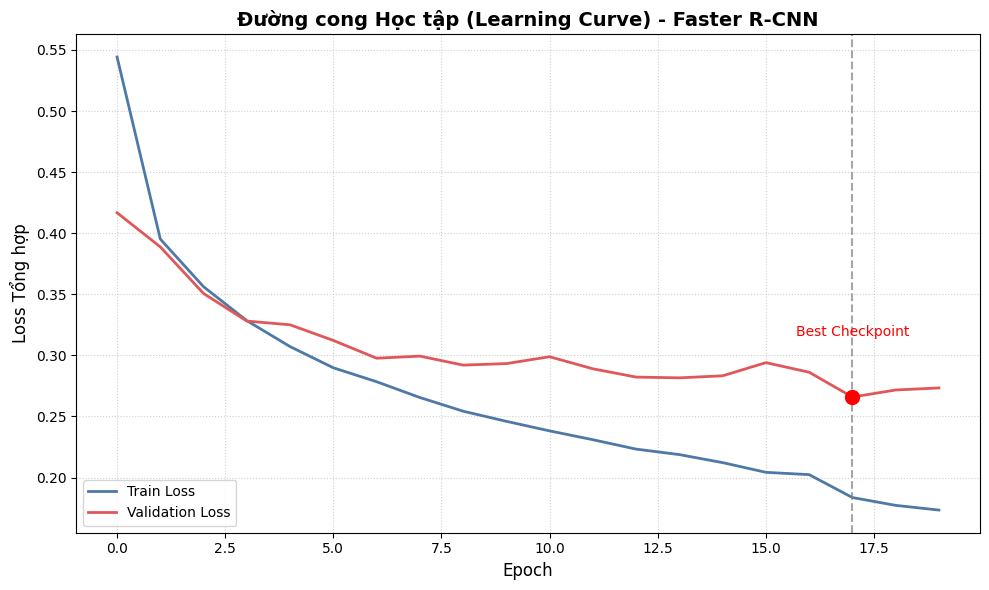

In [27]:
import torch
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
import matplotlib.pyplot as plt

# ============================================================
# 1. CẤU HÌNH SIÊU THAM SỐ (HYPERPARAMETERS)
# ============================================================
EPOCHS = 20
LR = 0.005
PATIENCE = 4 # Early stopping nếu Val Loss không giảm sau 4 epoch
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
MODEL_NAME = "Faster_RCNN_KITTI"
SAVE_PATH = "kitti_faster_rcnn_best.pth"

# ============================================================
# 2. KHỞI TẠO MÔ HÌNH FASTER R-CNN
# ============================================================
print(f"Đang khởi tạo mô hình trên thiết bị: {DEVICE}...")

# Tải pre-trained model (ResNet50 + FPN) đã được train trên COCO
model = torchvision.models.detection.fasterrcnn_resnet50_fpn(pretrained=True)

# Lấy số chiều in_features của lớp phân loại cuối cùng
in_features = model.roi_heads.box_predictor.cls_score.in_features

# Thay thế Head cũ bằng Head mới tương ứng với số lớp của KITTI
# Lưu ý: NUM_CLASSES = 7 (Bao gồm 6 lớp vật thể + 1 lớp Background bắt buộc)
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, NUM_CLASSES)
model.to(DEVICE)

# ============================================================
# 3. KÍCH HOẠT QUÁ TRÌNH HUẤN LUYỆN (TRAINING)
# ============================================================
# Gọi hàm vòng lặp chúng ta vừa định nghĩa ở trên
history = train_and_evaluate_rcnn(
    model_name=MODEL_NAME,
    model=model,
    train_loader=train_dl,
    val_loader=val_dl,
    epochs=EPOCHS,
    lr=LR,
    device=DEVICE,
    patience=PATIENCE,
    save_path=SAVE_PATH
)

# ============================================================
# 4. ĐÁNH GIÁ TRÊN TẬP TEST (EVALUATION)
# ============================================================
test_loss = evaluate_on_test_rcnn(
    model=model,
    test_loader=test_dl,
    device=DEVICE,
    checkpoint_path=SAVE_PATH
)

# ============================================================
# 5. TRỰC QUAN HÓA LỊCH SỬ HUẤN LUYỆN (LEARNING CURVE)
# ============================================================
plt.figure(figsize=(10, 6))
plt.plot(history['train_loss'], label='Train Loss', color='#4e79a7', linewidth=2)
plt.plot(history['val_loss'], label='Validation Loss', color='#e15759', linewidth=2)

plt.title('Đường cong Học tập (Learning Curve) - Faster R-CNN', fontsize=14, fontweight='bold')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss Tổng hợp', fontsize=12)

# Hiển thị điểm Val Loss thấp nhất (điểm lưu Checkpoint)
best_epoch = history['val_loss'].index(min(history['val_loss']))
plt.axvline(x=best_epoch, color='grey', linestyle='--', alpha=0.7)
plt.scatter(best_epoch, history['val_loss'][best_epoch], color='red', s=100, zorder=5)
plt.text(best_epoch, history['val_loss'][best_epoch] + 0.05, 'Best Checkpoint', color='red', ha='center')

plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.savefig('faster_rcnn_learning_curve.png', bbox_inches='tight')
plt.show()

## YOLO

In [28]:
import os
import shutil
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from PIL import Image

# ============================================================
# 1. CẤU HÌNH THƯ MỤC & MAPPING 8 LỚP
# ============================================================
YOLO_DIR = Path('/kaggle/working/yolo_dataset')
IMG_DIR = Path("/kaggle/input/datasets/klemenko/kitti-dataset/data_object_image_2/training/image_2")

if YOLO_DIR.exists():
    shutil.rmtree(YOLO_DIR)

for split in ['train', 'val']:
    (YOLO_DIR / 'images' / split).mkdir(parents=True, exist_ok=True)
    (YOLO_DIR / 'labels' / split).mkdir(parents=True, exist_ok=True)

CLASS_MAP = {
    'Car': 0, 'Van': 1, 'Truck': 2,
    'Pedestrian': 3, 'Person_sitting': 4,
    'Cyclist': 5, 'Tram': 6, 'Misc': 7
}

print("📂 Đã tạo xong cấu trúc thư mục YOLO!")

# ============================================================
# 2. XỬ LÝ LẠI DATAFRAME TRƯỚC KHI XUẤT
# ============================================================
print(f"🔍 Các cột hiện tại trong df: {df.columns.tolist()}")

# 2.1 Tự động dò tìm tên cột chứa phân lớp (class, type, label...)
if 'class_id' not in df.columns:
    # Nếu chưa có class_id, ta đi tìm cột chứa tên chữ để map
    possible_class_cols = ['class', 'type', 'label', 'class_name']
    class_col = next((col for col in possible_class_cols if col in df.columns), None)
    
    if class_col:
        print(f"✅ Đã tìm thấy cột nhãn chữ là: '{class_col}'")
        df['class_id'] = df[class_col].map(CLASS_MAP)
    else:
        raise ValueError("❌ Không tìm thấy cột nào chứa tên lớp! Vui lòng kiểm tra lại df.")

# Loại bỏ các dòng bị NaN (ví dụ nhãn 'DontCare' không có trong CLASS_MAP)
df = df.dropna(subset=['class_id']).copy() 

# Tự động dò tìm tên cột chứa ID ảnh
id_col = 'id' if 'id' in df.columns else 'img_idx'

# 2.2 Chia tập Train/Val ngẫu nhiên (Tỷ lệ 80/20)
if 'split' not in df.columns:
    unique_imgs = df[id_col].unique()
    train_imgs, val_imgs = train_test_split(unique_imgs, test_size=0.2, random_state=42)
    
    def assign_split(img_id):
        return 'train' if img_id in train_imgs else 'val'
        
    df['split'] = df[id_col].apply(assign_split)

# 2.3 Kiểm tra tình trạng các cột tọa độ chuẩn hóa
if all(col in df.columns for col in ['cx_norm', 'cy_norm', 'w_norm', 'h_norm']):
    pre_calculated = True
else:
    print("⚠️ Thiếu cột chuẩn hóa (cx_norm...). Sẽ tự động tính toán lại từ ảnh gốc.")
    pre_calculated = False

# ============================================================
# 3. TIẾN HÀNH CHUYỂN ĐỔI SANG YOLO FORMAT
# ============================================================
grouped = df.groupby([id_col, 'split'])

print("⏳ Đang chuyển đổi và copy dữ liệu sang YOLO Format...")
for (img_id, split), group in tqdm(grouped, total=len(grouped)):
    src_img = IMG_DIR / f"{img_id}.png"
    dst_img = YOLO_DIR / 'images' / split / f"{img_id}.png"
    dst_lbl = YOLO_DIR / 'labels' / split / f"{img_id}.txt"
    
    if not src_img.exists():
        continue 
        
    # Copy ảnh sang thư mục YOLO
    shutil.copy(src_img, dst_img)
    
    # Tính lại kích thước nếu bị mất cột
    if not pre_calculated:
        with Image.open(src_img) as im:
            w_img, h_img = im.size
            
    # Ghi file txt
    with open(dst_lbl, 'w') as f:
        for _, row in group.iterrows():
            cls_id = int(row['class_id'])
            
            if pre_calculated:
                cx, cy, w, h = row['cx_norm'], row['cy_norm'], row['w_norm'], row['h_norm']
            else:
                cx = ((row['x1'] + row['x2']) / 2) / w_img
                cy = ((row['y1'] + row['y2']) / 2) / h_img
                w = (row['x2'] - row['x1']) / w_img
                h = (row['y2'] - row['y1']) / h_img
                
            cx, cy, w, h = np.clip([cx, cy, w, h], 0.0, 1.0)
            f.write(f"{cls_id} {cx:.6f} {cy:.6f} {w:.6f} {h:.6f}\n")

print("✅ Chuyển đổi dữ liệu YOLO hoàn tất!")

📂 Đã tạo xong cấu trúc thư mục YOLO!
🔍 Các cột hiện tại trong df: ['img_idx', 'class_id', 'x1', 'y1', 'x2', 'y2']
⚠️ Thiếu cột chuẩn hóa (cx_norm...). Sẽ tự động tính toán lại từ ảnh gốc.
⏳ Đang chuyển đổi và copy dữ liệu sang YOLO Format...


100%|██████████| 7481/7481 [00:25<00:00, 294.48it/s]

✅ Chuyển đổi dữ liệu YOLO hoàn tất!


In [29]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 44.5 MB/s eta 0:00:00


In [30]:
import gc
# ============================================================
# 0. DỌN DẸP VRAM (GIẢI PHÓNG BỘ NHỚ TỪ FASTER R-CNN CŨ)
# ============================================================
print("Đang dọn dẹp bộ nhớ GPU...")
gc.collect()
torch.cuda.empty_cache()
print(f"VRAM khả dụng: {torch.cuda.memory_allocated() / 1024**2:.2f} MB đang dùng.")

Đang dọn dẹp bộ nhớ GPU...
VRAM khả dụng: 339.63 MB đang dùng.


In [31]:
import yaml
from pathlib import Path
from ultralytics import YOLO

# ============================================================
# 1. TẠO FILE CẤU HÌNH YAML (TỰ ĐỘNG)
# ============================================================
YOLO_DIR = Path('/kaggle/working/yolo_dataset')
yaml_path = YOLO_DIR / 'kitti_data.yaml'

CLASS_NAMES = ['Car', 'Van', 'Truck', 'Pedestrian', 'Person_sitting', 'Cyclist', 'Tram', 'Misc']

yaml_data = {
    'path': str(YOLO_DIR.absolute()), 
    'train': 'images/train',
    'val': 'images/val',
    'test': 'images/test',
    'nc': len(CLASS_NAMES),
    'names': CLASS_NAMES
}

# Tạo thư mục yolo_dataset nếu vô tình bị xóa
YOLO_DIR.mkdir(parents=True, exist_ok=True)

# Ghi file YAML
with open(yaml_path, 'w') as f:
    yaml.dump(yaml_data, f, sort_keys=False)

print(f"📄 Đã tạo thành công file cấu hình tại: {yaml_path}")

# ============================================================
# 2. KHỞI TẠO VÀ HUẤN LUYỆN YOLOv8 (MULTI-GPU)
# ============================================================
MODEL_WEIGHT = 'yolov8m.pt' 

print(f"🚀 Khởi tạo mô hình {MODEL_WEIGHT}...")
model = YOLO(MODEL_WEIGHT)

# Bắt đầu quá trình Training
results = model.train(
    data=str(yaml_path),   
    epochs=20,
    imgsz=640,             
    batch=32,
    device=[0, 1],
    workers=4,
    patience=5,            
    optimizer='auto',      
    lr0=0.01,              
    mosaic=1.0,            
    project='YOLOv8_KITTI',
    name='train_run'
)

print("Huấn luyện YOLOv8 Multi-GPU hoàn tất!")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
📄 Đã tạo thành công file cấu hình tại: /kaggle/working/yolo_dataset/kitti_data.yaml
🚀 Khởi tạo mô hình yolov8m.pt...
Ultralytics 8.4.34 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
                                                       CUDA:1 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/yolo_dataset/kitti_data.yaml, degrees=0.0, deterministic=True, device=0,1, dfl=1.5, dnn=False, dropout=0.0

/usr/local/lib/python3.12/dist-packages/ultralytics/utils/metrics.py:75: UserWarning: Specified kernel cache directory could not be created! This disables kernel caching. Specified directory is /root/.cache/torch/kernels. This warning will appear only once per process. (Triggered internally at /pytorch/aten/src/ATen/native/cuda/jit_utils.cpp:1487.)
  inter = (torch.min(a2, b2) - torch.max(a1, b1)).clamp_(0).prod(2)


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 24/24 2.9it/s 8.4s
                   all       1497       8231      0.676      0.515      0.574      0.357

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       2/20      6.52G       1.11     0.8206      1.047        187        640: 100% ━━━━━━━━━━━━ 187/187 1.8it/s 1:47
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 24/24 3.2it/s 7.4s
                   all       1497       8231      0.713      0.514      0.595      0.365

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       3/20      6.53G      1.074     0.7717       1.03        160        640: 100% ━━━━━━━━━━━━ 187/187 1.8it/s 1:47
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 24/24 3.2it/s 7.6s
                   all       1497       8231   

In [32]:
# ============================================================
# 3. ĐÁNH GIÁ TỰ ĐỘNG TRÊN TẬP VAL (VÌ KHÔNG CÓ TẬP TEST RỜI)
# ============================================================
print("\n🔍 Đang đánh giá trên tập Val...")

# SỬA LỖI: Đổi split='test' thành split='val'
metrics = model.val(split='val', device=0)

# In kết quả
print(f"✅ mAP50-95 trên tập Val: {metrics.box.map:.4f}")
print(f"✅ mAP50 trên tập Val   : {metrics.box.map50:.4f}")


🔍 Đang đánh giá trên tập Val...
Ultralytics 8.4.34 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 93 layers, 25,844,392 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 4264.3±1141.3 MB/s, size: 784.6 KB)
val: Scanning /kaggle/working/yolo_dataset/labels/val.cache... 1497 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1497/1497 330.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 94/94 5.2it/s 18.1s
                   all       1497       8231      0.863      0.858      0.903      0.673
                   Car       1338       5889      0.903      0.936      0.966      0.804
                   Van        427        570      0.893      0.933      0.967      0.775
                 Truck        220        227      0.952      0.969      0.985      0.851
            Pedestrian        359        916      0.875       0.74      0.833      0.4

In [33]:
import time
import torch
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.transforms import functional as F
from PIL import Image
from ultralytics import YOLO
from pathlib import Path

print("⏳ Đang tiến hành đo lường FPS cho cả 2 mô hình (trên 100 ảnh Val)...")
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ============================================================
# 1. CHUẨN BỊ DỮ LIỆU ĐO LƯỜNG (TẬP VAL)
# ============================================================
YOLO_DIR = Path('/kaggle/working/yolo_dataset')

# Lấy 100 ảnh từ tập Val (vì tập Test không tồn tại)
val_img_paths = list((YOLO_DIR / 'images' / 'val').glob('*.png'))[:100]

if not val_img_paths:
    raise FileNotFoundError("❌ Không tìm thấy ảnh trong tập val! Hãy kiểm tra lại thư mục.")

# Chuẩn bị sẵn 100 Tensors cho Faster R-CNN để không bị tính thời gian load ảnh vào FPS
rcnn_tensors = [F.to_tensor(Image.open(p).convert("RGB")).to(DEVICE) for p in val_img_paths]

# ============================================================
# 2. BENCHMARK FASTER R-CNN
# ============================================================
print("⚙️ Đang setup cấu hình Faster R-CNN...")
# Khởi tạo lại model với biến mới để tránh đụng độ YOLO
rcnn_model = torchvision.models.detection.fasterrcnn_resnet50_fpn(pretrained=False)
in_features = rcnn_model.roi_heads.box_predictor.cls_score.in_features
rcnn_model.roi_heads.box_predictor = FastRCNNPredictor(in_features, 9) # 8 lớp + 1 Background
rcnn_model.to(DEVICE)
rcnn_model.eval()

print("🔥 Warm-up Faster R-CNN...")
with torch.no_grad():
    for i in range(5):
        rcnn_model([rcnn_tensors[i]])

print("⏱️ Bắt đầu đo Faster R-CNN...")
t0_rcnn = time.time()
with torch.no_grad():
    for tensor in rcnn_tensors:
        rcnn_model([tensor])
        
rcnn_fps = 100 / (time.time() - t0_rcnn)

# ============================================================
# 3. BENCHMARK YOLOv8 (Bản Medium)
# ============================================================
print("\n⚙️ Đang setup cấu hình YOLOv8...")
# Dùng hàm glob để tự động tìm thư mục train_run mới nhất (ví dụ: train_run4)
yolo_runs = sorted(Path('/kaggle/working/runs/detect/YOLOv8_KITTI').glob('train_run*'))
latest_run = yolo_runs[-1] if yolo_runs else Path('YOLOv8_KITTI/train_run')
yolo_best_path = latest_run / 'weights' / 'best.pt'

yolo_best = YOLO(str(yolo_best_path))

print("🔥 Warm-up YOLOv8...")
for p in val_img_paths[:5]:
    yolo_best.predict(str(p), verbose=False, device=0)

print("⏱️ Bắt đầu đo YOLOv8...")
t0_yolo = time.time()
for p in val_img_paths:
    yolo_best.predict(str(p), verbose=False, device=0)

yolo_fps = 100 / (time.time() - t0_yolo)

# ============================================================
# 4. KẾT QUẢ SO SÁNH
# ============================================================
print("\n" + "=" * 50)
print("🏆 KẾT QUẢ BENCHMARK TỐC ĐỘ INFERENCE (FPS) 🏆")
print("=" * 50)
print(f"🐌 Faster R-CNN (ResNet50) : {rcnn_fps:.1f} FPS")
print(f"🚀 YOLOv8m                 : {yolo_fps:.1f} FPS")
print("=" * 50)

⏳ Đang tiến hành đo lường FPS cho cả 2 mô hình (trên 100 ảnh Val)...
⚙️ Đang setup cấu hình Faster R-CNN...


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning:

The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning:

Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.



Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 191MB/s]


🔥 Warm-up Faster R-CNN...
⏱️ Bắt đầu đo Faster R-CNN...

⚙️ Đang setup cấu hình YOLOv8...
🔥 Warm-up YOLOv8...
⏱️ Bắt đầu đo YOLOv8...

🏆 KẾT QUẢ BENCHMARK TỐC ĐỘ INFERENCE (FPS) 🏆
🐌 Faster R-CNN (ResNet50) : 7.0 FPS
🚀 YOLOv8m                 : 45.4 FPS


Đã lưu ảnh: rcnn_learning_curve.png


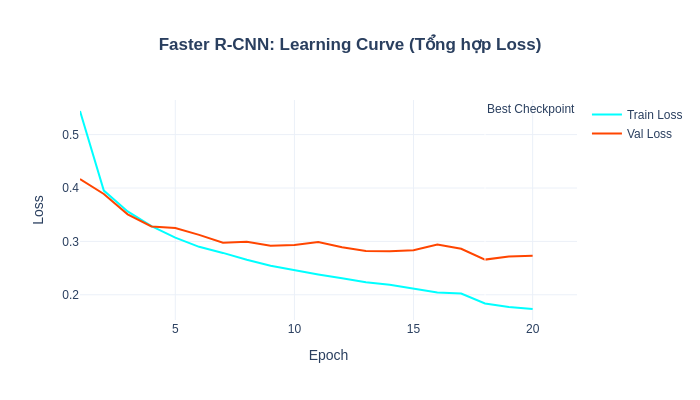

✅ Đang đọc dữ liệu YOLO từ: /kaggle/working/runs/detect/YOLOv8_KITTI/train_run/results.csv
Đã lưu ảnh: yolo_learning_curves.png


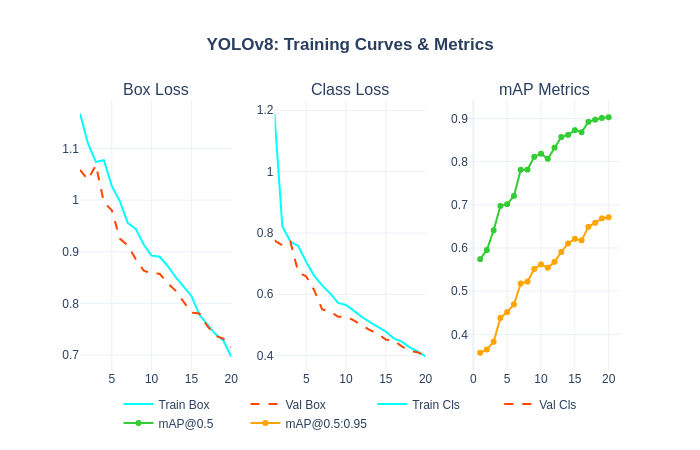

In [34]:
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from pathlib import Path

# ============================================================
# BIỂU ĐỒ 1: ĐƯỜNG CONG HỌC TẬP FASTER R-CNN (TỪ BIẾN `history`)
# ============================================================
fig_rcnn = go.Figure()

# Kiểm tra xem biến history có tồn tại trong bộ nhớ không
if 'history' in locals() or 'history' in globals():
    epochs = list(range(1, len(history['train_loss']) + 1))
    
    fig_rcnn.add_trace(go.Scatter(x=epochs, y=history['train_loss'], mode='lines', name='Train Loss', line=dict(color='#00FFFF', width=2)))
    fig_rcnn.add_trace(go.Scatter(x=epochs, y=history['val_loss'], mode='lines', name='Val Loss', line=dict(color='#FF4500', width=2)))
    
    # Đánh dấu epoch có Val Loss thấp nhất (Best Checkpoint)
    best_epoch = history['val_loss'].index(min(history['val_loss']))
    fig_rcnn.add_vline(x=best_epoch + 1, line_width=1, line_dash="dash", line_color="white", annotation_text="Best Checkpoint")

    fig_rcnn.update_layout(
        title_text='<b>Faster R-CNN: Learning Curve (Tổng hợp Loss)</b>',
        title_x=0.5, height=400, template='plotly_white', # ĐỔI SANG DARK MODE
        xaxis_title='Epoch', yaxis_title='Loss'
    )
    
    try:
        save_and_show_plotly(fig_rcnn, "rcnn_learning_curve.png")
    except NameError:
        fig_rcnn.show() # Backup nếu hàm chưa được nạp
else:
    print("⚠️ Không tìm thấy biến `history` của Faster R-CNN trong bộ nhớ (Có thể do bạn đã restart Kernel).")

# ============================================================
# BIỂU ĐỒ 2: ĐƯỜNG CONG HỌC TẬP YOLOv8m (TỰ ĐỘNG TÌM FILE MỚI NHẤT)
# ============================================================
# Tự động dò tìm thư mục train_run mới nhất trong thư mục runs/detect/
yolo_base_dir = Path('/kaggle/working/runs/detect/YOLOv8_KITTI')
yolo_runs = sorted(yolo_base_dir.glob('train_run*'))

if yolo_runs:
    latest_run = yolo_runs[-1]
    results_csv = latest_run / 'results.csv'
    print(f"✅ Đang đọc dữ liệu YOLO từ: {results_csv}")
else:
    # Backup tìm ở thư mục hiện tại nếu không có trong runs/detect/
    yolo_runs = sorted(Path('/kaggle/working/YOLOv8_KITTI').glob('train_run*'))
    results_csv = yolo_runs[-1] / 'results.csv' if yolo_runs else Path('not_found')

if results_csv.exists():
    df_yolo = pd.read_csv(results_csv)
    df_yolo.columns = df_yolo.columns.str.strip() # Xóa khoảng trắng thừa trong tên cột
    
    fig_yolo = make_subplots(rows=1, cols=3, 
                        subplot_titles=('Box Loss', 'Class Loss', 'mAP Metrics'),
                        horizontal_spacing=0.08)

    # Ô 1: Box Loss
    fig_yolo.add_trace(go.Scatter(x=df_yolo['epoch'], y=df_yolo['train/box_loss'], mode='lines', name='Train Box', line=dict(color='#00FFFF', width=2)), row=1, col=1)
    fig_yolo.add_trace(go.Scatter(x=df_yolo['epoch'], y=df_yolo['val/box_loss'], mode='lines', name='Val Box', line=dict(color='#FF4500', width=2, dash='dash')), row=1, col=1)

    # Ô 2: Class Loss
    fig_yolo.add_trace(go.Scatter(x=df_yolo['epoch'], y=df_yolo['train/cls_loss'], mode='lines', name='Train Cls', line=dict(color='#00FFFF', width=2)), row=1, col=2)
    fig_yolo.add_trace(go.Scatter(x=df_yolo['epoch'], y=df_yolo['val/cls_loss'], mode='lines', name='Val Cls', line=dict(color='#FF4500', width=2, dash='dash')), row=1, col=2)

    # Ô 3: mAP Metrics
    fig_yolo.add_trace(go.Scatter(x=df_yolo['epoch'], y=df_yolo['metrics/mAP50(B)'], mode='lines+markers', name='mAP@0.5', line=dict(color='#32CD32', width=2)), row=1, col=3)
    fig_yolo.add_trace(go.Scatter(x=df_yolo['epoch'], y=df_yolo['metrics/mAP50-95(B)'], mode='lines+markers', name='mAP@0.5:0.95', line=dict(color='#FFA500', width=2)), row=1, col=3)

    fig_yolo.update_layout(
        title_text='<b>YOLOv8: Training Curves & Metrics</b>',
        title_x=0.5, height=450, template='plotly_white', # ĐỔI SANG DARK MODE
        legend=dict(orientation="h", yanchor="bottom", y=-0.25, xanchor="center", x=0.5)
    )
    
    try:
        save_and_show_plotly(fig_yolo, "yolo_learning_curves.png")
    except NameError:
        fig_yolo.show()
else:
    print("❌ Vẫn không tìm thấy file `results.csv` của YOLO. Bạn hãy kiểm tra lại đường dẫn lưu model!")